Full code for Regex Information Extraction Model & Evaluation Results (using PAPER DATA split)

In [ ]:
import pandas as pd
import re
import numpy as np
import os
import sklearn
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Function to convert Roman numerals to integers
def roman_to_int(roman):
    roman_dict = {'I': 1, 'II': 2, 'III': 3, 'IV': 4}
    return roman_dict.get(roman.upper(), None)

The first dataset contains mostly BREAST and COLORECTAL samples

The second csv is a separate dataset containing THYROID and PROSTATE SAMPLES

In [ ]:
df = pd.read_csv('/content/combined_Ground_truth_validated.csv')
df

,mrn,TOPO,MORP,GRADE,T,N,M,STAGE,LATER,TRE-1,text
0,1082698,BREAST,infiltrating or invasive ductal carcinoma of n...,grade 3 or grade III; also called poorly diffe...,t3,n0,m0,iib,left,surgery+chemotherapy+radiotherapy+hormonal,Authorised by Ritu Lakhtakia on 22/...
1,1092552,BREAST,infiltrating or invasive ductal carcinoma of n...,grade 3 or grade III; also called poorly diffe...,t4b,n0,m0,iiia,right,neoadjuvant chemotherapy+surgery+radiotherapy+...,Authorised by Ibrahim Al Haddabi on...
2,1279594,COLORECTAL,adenocarcinoma of no special type,grade 2 or grade II; also called moderately d...,t3,n1,mx,iiib,"right, transverse colon",chemotherapy + surgery,"""For Follow up colonoscopyHistory as follows:D..."
3,1389006,COLORECTAL,adenocarcinoma of no special type,grade 2 or grade II; also called moderately d...,t3,n0,m0,iib,left,chemotherapy + surgery,"""Oncology DCU ""\r\n*****************\r\nVisit ..."
4,1215135,BREAST,mucinous carcinoma,grade 2 or grade II; also called moderately d...,t2,n0,m0,iia,left,surgery+chemotherapy+radiotherapy+hormonal,Authorised by Dr. Asem Shalaby on 0...
...,...,...,...,...,...,...,...,...,...,...,...
415,1278681,BREAST,infiltrating or invasive ductal carcinoma of n...,grade 3 or grade III; also called poorly diffe...,t2,n1,m0,iib,left,surgery+chemotherapy+radiotherapy+hormonal,Authorised by Ritu Lakhtakia on 29/...
416,1185971,BREAST,infiltrating or invasive ductal carcinoma of n...,grade 2 or grade II; also called moderately d...,t4b,n2,m0,iiic,left,neoadjuvant chemotherapy+surgery+radiotherapy+...,Authorised by Mohammed Mahmoud Moham...
417,1147311,BREAST,infiltrating or invasive ductal carcinoma of n...,grade 2 or grade II; also called moderately d...,t2,n0,mx,iia,right,surgery,Authorised by Mohammed Mahmoud Moham...
418,1398841,BREAST,infiltrating or invasive ductal carcinoma of n...,grade 2 or grade II; also called moderately d...,t2,n0,mx,iia,left,chemotherapy,Authorised by Dr. Maiya Abdullah Al-...


In [ ]:
df2 = pd.read_csv('/content/prostate_thyroid_samples.csv')
df2 = df2.rename(columns={'PATIENT ID': 'mrn'})
df2

,mrn,TOPO,MORP,GRADE,T,N,M,STAGE,LATER,TRE-1,text,site
0,1237,PROSTATE,acinar adenocarcinoma,group 5 (gleason score 5 + 4 = 9),t3b,n1,m0,iva,unknown,combination ( surgery+ hormonal therapy +radia...,Elderly man with biochemical and limited radio...,prostate
1,2321,PROSTATE,acinar adenocarcinoma,group 4 (gleason score 4 + 4 = 8),t2,nx,mx,unknown,bilateral involvement,combination ( surgery+ hormonal therapy +radia...,DOA: 25/6/2018\r\nDOD: 1/7/2018\r\n===========...,prostate
2,5062,PROSTATE,acinar adenocarcinoma,group 4 (gleason score 4 + 4 = 8),t2,n0,m0,unknown,left,combination ( hormonal therapy +radiation ther...,"""Cardiology clinic follow up ""\r\n============...",prostate
3,7864,PROSTATE,acinar adenocarcinoma,group 5 (gleason score 4 + 5 = 9),t3b,n1,m1b,iv,bilateral involvement,combination ( surgery+ hormonal therapy +radia...,Diagnosis: Stage IV Prostate Cancer with progr...,prostate_colon
4,27228,PROSTATE,acinar adenocarcinoma,group 1 (gleason score 3 + 3 = 6),t1a,nx,mx,i,unknown,active surveillance,On AS for prostate cancerPSA 1.3 stable last o...,prostate
...,...,...,...,...,...,...,...,...,...,...,...,...
185,1359023,THYROID,papillary carcinoma,unknown,unknown,unknown,unknown,i,unknown,total thyroidectomy,post Total Thyroidectomy for graves and Thy5 F...,thyroid
186,1365405,THYROID,papillary carcinoma,unknown,unknown,unknown,unknown,i,unknown,total thyroidectomy,Exit round with Dr.Omar and the oncall team\r\...,thyroid
187,1365411,THYROID,papillary carcinoma,unknown,unknown,unknown,unknown,i,unknown,total thyroidectomy,"""papillary thyroid cancer 4 cmpost I131 x 1TG ...",thyroid
188,1365420,THYROID,papillary carcinoma,unknown,unknown,n1,unknown,i,unknown,total thyroidectomy,F-Updoing wellwound cleanneck flatPath:14 out ...,thyroid


In [ ]:
df = pd.concat([df, df2], ignore_index=True)
df

,mrn,TOPO,MORP,GRADE,T,N,M,STAGE,LATER,TRE-1,text,site
0,1082698,BREAST,infiltrating or invasive ductal carcinoma of n...,grade 3 or grade III; also called poorly diffe...,t3,n0,m0,iib,left,surgery+chemotherapy+radiotherapy+hormonal,Authorised by Ritu Lakhtakia on 22/...,NaN
1,1092552,BREAST,infiltrating or invasive ductal carcinoma of n...,grade 3 or grade III; also called poorly diffe...,t4b,n0,m0,iiia,right,neoadjuvant chemotherapy+surgery+radiotherapy+...,Authorised by Ibrahim Al Haddabi on...,NaN
2,1279594,COLORECTAL,adenocarcinoma of no special type,grade 2 or grade II; also called moderately d...,t3,n1,mx,iiib,"right, transverse colon",chemotherapy + surgery,"""For Follow up colonoscopyHistory as follows:D...",NaN
3,1389006,COLORECTAL,adenocarcinoma of no special type,grade 2 or grade II; also called moderately d...,t3,n0,m0,iib,left,chemotherapy + surgery,"""Oncology DCU ""\r\n*****************\r\nVisit ...",NaN
4,1215135,BREAST,mucinous carcinoma,grade 2 or grade II; also called moderately d...,t2,n0,m0,iia,left,surgery+chemotherapy+radiotherapy+hormonal,Authorised by Dr. Asem Shalaby on 0...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
605,1359023,THYROID,papillary carcinoma,unknown,unknown,unknown,unknown,i,unknown,total thyroidectomy,post Total Thyroidectomy for graves and Thy5 F...,thyroid
606,1365405,THYROID,papillary carcinoma,unknown,unknown,unknown,unknown,i,unknown,total thyroidectomy,Exit round with Dr.Omar and the oncall team\r\...,thyroid
607,1365411,THYROID,papillary carcinoma,unknown,unknown,unknown,unknown,i,unknown,total thyroidectomy,"""papillary thyroid cancer 4 cmpost I131 x 1TG ...",thyroid
608,1365420,THYROID,papillary carcinoma,unknown,unknown,n1,unknown,i,unknown,total thyroidectomy,F-Updoing wellwound cleanneck flatPath:14 out ...,thyroid


In [ ]:
# Check for duplicates in the 'mrn' column
duplicates = df[df.duplicated(subset=['mrn'], keep=False)]

if not duplicates.empty:
    print("Duplicate MRN values found:")
    display(duplicates.sort_values(by='mrn'))
else:
    print("No duplicate MRN values found.")

Duplicate MRN values found:


,mrn,TOPO,MORP,GRADE,T,N,M,STAGE,LATER,TRE-1,text,site
176,25326,BREAST,infiltrating or invasive ductal carcinoma of n...,grade 2 or grade II; also called moderately d...,t1c,n0,mx,i,left,surgery+hormonal,Authorised by Dr. Asim Qureshi on 2...,NaN
411,25326,BREAST,infiltrating or invasive ductal carcinoma of n...,grade 2 or grade II; also called moderately d...,t1c,n0,mx,i,left,surgery+hormonal,Authorised by Dr. Asim Qureshi on 2...,NaN
435,130682,PROSTATE,acinar adenocarcinoma,group 5 (gleason score 5 + 4 = 9),t1c,nx,mx,unknown,bilateral involvement,combination ( hormonal therapy +radiation ther...,"""cT3N1M0, prostate cancer ""\r\n""EBRT to whole ...",prostate
233,130682,PROSTATE,acinar adenocarcinoma,group 5 (gleason score 5 + 4 = 9),t1c,nx,mx,unknown,bilateral involvement,combination ( hormonal therapy +radiation ther...,"""cT3N1M0, prostate cancer ""\r\n""EBRT to whole ...",NaN
382,187290,PROSTATE,unknown,unknown,unknown,unknown,unknown,unknown,unknown,radical prostatectomy,"""2 months post RRP for cT2cN0M0 prostate cance...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
247,1360922,PROSTATE,acinar adenocarcinoma,group 2 (gleason score 3 + 4 = 7),t1c,nx,mx,unknown,bilateral involvement,combination ( hormonal therapy +radiation ther...,"MDT (20/08/2017)\r\n""The meeting was attended ...",NaN
352,1368737,PROSTATE,acinar adenocarcinoma,group 2 (gleason score 3 + 4 = 7),t1c,nx,mx,unknown,unknown,unknown,"59 years old male, no co morbidsrising PSA (5....",NaN
514,1368737,PROSTATE,acinar adenocarcinoma,group 2 (gleason score 3 + 4 = 7),t1c,nx,mx,unknown,unknown,unknown,"59 years old male, no co morbidsrising PSA (5....",prostate
162,1394942,BREAST,infiltrating or invasive ductal carcinoma of n...,grade 2 or grade II; also called moderately d...,t2,n0,mx,iia,left,surgery,Authorised by Dr.Radiya Al-Ajmi on ...,NaN


In [ ]:
print(df['TOPO'].value_counts())

TOPO
BREAST        310
PROSTATE      114
COLORECTAL     94
THYROID        91
RECTUM          1
Name: count, dtype: int64


In [ ]:
df.drop_duplicates(subset=['mrn'], keep='first', inplace=True)
print("Duplicates dropped based on 'mrn' column, keeping the first occurrence.")
display(df)
print(df['TOPO'].value_counts())

Duplicates dropped based on 'mrn' column, keeping the first occurrence.


,mrn,TOPO,MORP,GRADE,T,N,M,STAGE,LATER,TRE-1,text,site
0,1082698,BREAST,infiltrating or invasive ductal carcinoma of n...,grade 3 or grade III; also called poorly diffe...,t3,n0,m0,iib,left,surgery+chemotherapy+radiotherapy+hormonal,Authorised by Ritu Lakhtakia on 22/...,NaN
1,1092552,BREAST,infiltrating or invasive ductal carcinoma of n...,grade 3 or grade III; also called poorly diffe...,t4b,n0,m0,iiia,right,neoadjuvant chemotherapy+surgery+radiotherapy+...,Authorised by Ibrahim Al Haddabi on...,NaN
2,1279594,COLORECTAL,adenocarcinoma of no special type,grade 2 or grade II; also called moderately d...,t3,n1,mx,iiib,"right, transverse colon",chemotherapy + surgery,"""For Follow up colonoscopyHistory as follows:D...",NaN
3,1389006,COLORECTAL,adenocarcinoma of no special type,grade 2 or grade II; also called moderately d...,t3,n0,m0,iib,left,chemotherapy + surgery,"""Oncology DCU ""\r\n*****************\r\nVisit ...",NaN
4,1215135,BREAST,mucinous carcinoma,grade 2 or grade II; also called moderately d...,t2,n0,m0,iia,left,surgery+chemotherapy+radiotherapy+hormonal,Authorised by Dr. Asem Shalaby on 0...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
605,1359023,THYROID,papillary carcinoma,unknown,unknown,unknown,unknown,i,unknown,total thyroidectomy,post Total Thyroidectomy for graves and Thy5 F...,thyroid
606,1365405,THYROID,papillary carcinoma,unknown,unknown,unknown,unknown,i,unknown,total thyroidectomy,Exit round with Dr.Omar and the oncall team\r\...,thyroid
607,1365411,THYROID,papillary carcinoma,unknown,unknown,unknown,unknown,i,unknown,total thyroidectomy,"""papillary thyroid cancer 4 cmpost I131 x 1TG ...",thyroid
608,1365420,THYROID,papillary carcinoma,unknown,unknown,n1,unknown,i,unknown,total thyroidectomy,F-Updoing wellwound cleanneck flatPath:14 out ...,thyroid


TOPO
BREAST        296
PROSTATE      104
COLORECTAL     91
THYROID        86
RECTUM          1
Name: count, dtype: int64


This cell contains all the function that perform information extraction

In [ ]:
# Function to extract the highest TNM values and only the letter-value
def extract_highest_tnm(text):
    # Regex to extract TNM values only (e.g., T2, N1, M0)
    regex_patterns = {
        "T(pred)": r"\b[pc]?\s*T([xX01234])\b", #r"[pc]?T([xX01234][a-d]?)",
        "N(pred)": r"[pc]?N([xX0123])",
        "M(pred)": r"M([xX01])"
    }

    extracted = {key: re.findall(pattern, text) for key, pattern in regex_patterns.items()}

    # Function to determine the highest value for each category
    def get_highest(values, tnm_type):
        if not values:
            return None  # No match found

        # Sorting rules: Convert to numerical values while keeping 'X' as lowest priority
        def custom_sort(val):
            # Handle 'X' as lowest priority
            if val[0] in ('x', 'X'):
                return -1
            return int(val[0])  # Convert the numeric part to an integer for comparison

        # Sort values with 'X' at the bottom
        sorted_values = sorted(values, key=custom_sort, reverse=True)

        return tnm_type + sorted_values[0]  # Return formatted as T3, N2, etc.

    # Apply highest value selection
    final_tnm = {key: get_highest(values, key[0]) for key, values in extracted.items()}

    return final_tnm

def extract_information(row_text):
    """
    Extract specific labels (topology, morphology, grade, etc.) from text using regex patterns.

    Parameters:
    - row_text (str): Text content from the dataframe row.

    Returns:
    - dict: A dictionary with extracted information.
    """
    patterns = {
        "TOPO (pred)": r"[Bb]reast|[Cc]olon|[Rr]ectum|[Pp]rostate|[Tt]hyroid|[Rr]ectosigmoid",
        "MORP (pred)": (
            r"(?:DCIS|IDC|ILC|inv\.\s?duct\s?ca|invasive\sduct\s(?:carcinoma|ca)|"
            r"ductal\s(?:carcinoma|ca)|metastatic\sbreast\s(?:carcinoma|ca)|"
            r"mammary\s(?:carcinoma|ca)|invasive\sbreast\sca|"
            r"infiltrating\sduct\s(?:carcinoma|ca)|"
            r"invasive\s(?:lobular|tubular)\s(?:carcinoma|ca)|"
            r"metastatic\sbreast\slobular\s(?:carcinoma|ca)|"
            r"prostatic\s(?:acinar\s)?adenocarcinoma|"
            r"papillary\s(?:thyroid\s)?(?:carcinoma|ca|cancer)|"
            r"metastatic\spapillary\s(?:carcinoma|ca|cancer)|"
            r"multifocal\sclassical\spapillary\s(?:carcinoma|ca)|"
            r"[Mm]ucinous\s[Aa]denocarcinoma|[Nn]eoplasm|[Nn]euroendocrine|"
            r"[Ss]ignet\s[Rr]ing)"
        ),
        "GRADE (pred)": (
            r"(?:(?:[Tt]umour|[Nn]ottingham)?\s*[Gg]rade\s*[:-]?\s*(?:([1-4])|([IVX]{1,3})))"
            r"|(?:\bG\s*([1-4]|[IVX]{1,3})\b)"
        ),
        "STAGE (pred)": r"[Ss]tage\sI{1,3}[AaBbCc]{0,1}|[Ss]tage\sIV[AaBbCc]{0,1}|[Ss]tage\s[1-4][AaBbCc]{0,1}",
        "TRE (pred)": r"[Ss]urgery|[Cc]hemotherapy|[Rr]adiotherapy|[Hh]ormonal\s[Tt]herapy",
    }


    extracted_data = {}

    # Extract TNM values
    tnm_info = extract_highest_tnm(row_text)
    extracted_data.update(tnm_info)

    # Extract other information
    for key, pattern in patterns.items():
        matches = re.findall(pattern, row_text, re.IGNORECASE)

        # Flatten tuples (for cases where multiple capture groups exist)
        matches = [m for match in matches for m in match if m] if matches and isinstance(matches[0], tuple) else matches

        # Special handling for "GRADE (pred)" to select the highest grade
        if key == "GRADE (pred)" and matches:
            numerical_grades = []
            for match in matches:
                if match.isdigit():  # Convert numbers directly
                    numerical_grades.append(int(match))
                else:  # Convert Roman numerals if applicable
                    roman_value = roman_to_int(match)
                    if roman_value:
                        numerical_grades.append(roman_value)

            # Pick the highest grade
            extracted_data[key] = max(numerical_grades) if numerical_grades else np.nan
        elif key == "TRE (pred)":
            extracted_data[key] = ", ".join(set(m.capitalize() for m in matches)) if matches else np.nan
        else:
            extracted_data[key] = max(set(matches), key=matches.count).capitalize() if matches else np.nan

    return extracted_data


def process_dataframe(df):
    """
    Processes a DataFrame and extracts predictions for each row.

    Parameters:
    - df (pd.DataFrame): Input DataFrame with a `text` column.

    Returns:
    - pd.DataFrame: DataFrame with extracted predictions.
    """
    predictions = []

    for index, row in df.iterrows():
        text_content = row['text']
        extracted_data = extract_information(text_content)
        extracted_data['mrn'] = row.get('mrn', f"Row_{index}")  # Preserve MRN if available
        predictions.append(extracted_data)

    return pd.DataFrame(predictions)



In [ ]:
import re
import numpy as np

# Utility: Convert Roman numerals to integers (used for grades)
def roman_to_int(s):
    roman = {'I': 1, 'V': 5, 'X': 10}
    prev = total = 0
    for char in reversed(s.upper()):
        if roman[char] < prev:
            total -= roman[char]
        else:
            total += roman[char]
            prev = roman[char]
    return total if total > 0 else None

# Extract TNM info
def extract_highest_tnm(text):
    regex_patterns = {
        "T(pred)": r"\b[pc]?\s*T([xX01234])\b",
        "N(pred)": r"[pc]?N([xX0123])",
        "M(pred)": r"M([xX01])"
    }

    extracted = {key: re.findall(pattern, text) for key, pattern in regex_patterns.items()}

    def get_highest(values, tnm_type):
        if not values:
            return None
        def custom_sort(val):
            if val[0].lower() == 'x':
                return -1
            return int(val[0])
        sorted_values = sorted(values, key=custom_sort, reverse=True)
        return tnm_type + sorted_values[0]

    return {key: get_highest(values, key[0]) for key, values in extracted.items()}


# Main extraction function
def extract_information(row_text):
    patterns = {
        "TOPO (pred)": r"[Bb]reast|[Cc]olon|[Rr]ectum|[Pp]rostate|[Tt]hyroid|[Rr]ectosigmoid",
        "MORP (pred)": (
            r"(?:DCIS|IDC|ILC|inv\.\s?duct\s?ca|invasive\sduct\s(?:carcinoma|ca)|"
            r"ductal\s(?:carcinoma|ca)|metastatic\sbreast\s(?:carcinoma|ca)|"
            r"mammary\s(?:carcinoma|ca)|invasive\sbreast\sca|"
            r"infiltrating\sduct\s(?:carcinoma|ca)|"
            r"invasive\s(?:lobular|tubular)\s(?:carcinoma|ca)|"
            r"metastatic\sbreast\slobular\s(?:carcinoma|ca)|"
            r"prostatic\s(?:acinar\s)?adenocarcinoma|"
            r"papillary\s(?:thyroid\s)?(?:carcinoma|ca|cancer)|"
            r"metastatic\spapillary\s(?:carcinoma|ca|cancer)|"
            r"multifocal\sclassical\spapillary\s(?:carcinoma|ca)|"
            r"[Mm]ucinous\s[Aa]denocarcinoma|[Nn]eoplasm|[Nn]euroendocrine|"
            r"[Ss]ignet\s[Rr]ing)"
        ),
        "GRADE (pred)": (
            r"(?:(?:[Tt]umour|[Nn]ottingham)?\s*[Gg]rade\s*[:-]?\s*(?:([1-4])|([IVX]{1,3})))"
            r"|(?:\bG\s*([1-4]|[IVX]{1,3})\b)"
        ),
        "STAGE (pred)": r"[Ss]tage\sI{1,3}[AaBbCc]{0,1}|[Ss]tage\sIV[AaBbCc]{0,1}|[Ss]tage\s[1-4][AaBbCc]{0,1}",
        "TRE (pred)": r"[Ss]urgery|[Cc]hemotherapy|[Rr]adiotherapy|[Hh]ormonal\s[Tt]herapy",
        "LATER (pred)": (
            r"(?:\b(left|right)\s*(?:lobe|breast|thyroid|side|zone|region|quadrant|aspect)\b)|"
            r"(?:\b(left[-\s]?sided|right[-\s]?sided)\b)|"
            r"(?:\bon\s+(the\s+)?(left|right)\b)|"
            r"(?:\bbilateral(ly)?\b)|"
            r"(?:\bboth\s+(lobes|sides|breasts)\b)|"
            r"(?:\bpaired\b)|"
            r"(?:\blat(?:eral)?\.?\s+unknown\b)|"
            r"(?:\bmidline\b|\bcentral\b|\btransitional\s+zone\b)"
        )
    }

    extracted_data = {}

    # TNM
    tnm_info = extract_highest_tnm(row_text)
    extracted_data.update(tnm_info)

    for key, pattern in patterns.items():
        matches = re.findall(pattern, row_text, re.IGNORECASE)

        matches = [m for match in matches for m in match if m] if matches and isinstance(matches[0], tuple) else matches

        if key == "GRADE (pred)" and matches:
            numerical_grades = []
            for match in matches:
                if match.isdigit():
                    numerical_grades.append(int(match))
                else:
                    roman_value = roman_to_int(match)
                    if roman_value:
                        numerical_grades.append(roman_value)
            extracted_data[key] = max(numerical_grades) if numerical_grades else np.nan

        elif key == "TRE (pred)":
            extracted_data[key] = ", ".join(set(m.capitalize() for m in matches)) if matches else np.nan

        elif key == "LATER (pred)":
            norm_map = {
                "left": "left",
                "left-sided": "left",
                "right": "right",
                "right-sided": "right",
                "right, transverse colon": "right",
                "bilateral": "bilateral involvement",
                "bilaterally": "bilateral involvement",
                "both": "bilateral involvement",
                "paired": "unknown",
                "lat. unknown": "unknown",
                "midline": "midline",
                "central": "midline",
                "transitional zone": "midline"
            }

            for match in matches:
                if isinstance(match, tuple):  # e.g., (left, lobe), (on, right)
                    flattened = [x for x in match if x]
                    for token in flattened:
                        token_lower = token.lower()
                        if token_lower in norm_map:
                            extracted_data[key] = norm_map[token_lower]
                            break
                else:
                    token_lower = match.lower()
                    extracted_data[key] = norm_map.get(token_lower, "unknown")
                    break # Take the first matched laterality

        else:
            extracted_data[key] = max(set(matches), key=matches.count).capitalize() if matches else np.nan

    return extracted_data


# Apply to full DataFrame
def process_dataframe(df):
    predictions = []
    for index, row in df.iterrows():
        text_content = row['text']
        extracted_data = extract_information(text_content)
        extracted_data['mrn'] = row.get('mrn', f"Row_{index}")
        predictions.append(extracted_data)
    return pd.DataFrame(predictions)


In [ ]:
import re
import numpy as np

# Utility: Convert Roman numerals to integers (used for grades)
def roman_to_int(s):
    roman = {'I': 1, 'V': 5, 'X': 10}
    prev = total = 0
    for char in reversed(s.upper()):
        if roman[char] < prev:
            total -= roman[char]
        else:
            total += roman[char]
            prev = roman[char]
    return total if total > 0 else None

# Utility: Extract highest TNM values
def extract_highest_tnm(text):
    regex_patterns = {
        "T(pred)": r"\b[pc]?\s*T([xX01234])\b",
        "N(pred)": r"[pc]?N([xX0123])",
        "M(pred)": r"M([xX01])"
    }
    extracted = {key: re.findall(pattern, text) for key, pattern in regex_patterns.items()}
    def get_highest(values, tnm_type):
        if not values:
            return None
        def custom_sort(val):
            if val[0].lower() == 'x':
                return -1
            return int(val[0])
        sorted_values = sorted(values, key=custom_sort, reverse=True)
        return tnm_type + sorted_values[0]
    return {key: get_highest(values, key[0]) for key, values in extracted.items()}

# Utility: Extract laterality more robustly
def extract_laterality(text):
    text = text.lower()
    patterns = {
        "bilateral involvement": r"\bbilateral( involvement| disease| tumors| lesion)?\b",
        "left": r"\bleft( (lobe|side|breast|colon|thyroid|hemisphere|segment|tumor|mass))?\b|\bleft-sided\b|\bon (the )?left\b",
        "right": r"\bright( (lobe|side|breast|colon|thyroid|hemisphere|segment|tumor|mass))?\b|\bright-sided\b|\bon (the )?right\b",
        "midline": r"\bmidline\b|\bcentral\b|\btransitional zone\b",
        "unknown": r"\bpaired\b|\blat(?:eral)?\.?\s+unknown\b"
    }
    for label, pattern in patterns.items():
        if re.search(pattern, text):
            return label
    return np.nan

# Main extraction function
def extract_information(row_text):
    patterns = {
        "TOPO (pred)": r"[Bb]reast|[Cc]olon|[Rr]ectum|[Pp]rostate|[Tt]hyroid|[Rr]ectosigmoid",
        "MORP (pred)": (
            r"(?:DCIS|IDC|ILC|inv\.\s?duct\s?ca|invasive\sduct\s(?:carcinoma|ca)|"
            r"ductal\s(?:carcinoma|ca)|metastatic\sbreast\s(?:carcinoma|ca)|"
            r"mammary\s(?:carcinoma|ca)|invasive\sbreast\sca|"
            r"infiltrating\sduct\s(?:carcinoma|ca)|"
            r"invasive\s(?:lobular|tubular)\s(?:carcinoma|ca)|"
            r"metastatic\sbreast\slobular\s(?:carcinoma|ca)|"
            r"prostatic\s(?:acinar\s)?adenocarcinoma|"
            r"papillary\s(?:thyroid\s)?(?:carcinoma|ca|cancer)|"
            r"metastatic\spapillary\s(?:carcinoma|ca|cancer)|"
            r"multifocal\sclassical\spapillary\s(?:carcinoma|ca)|"
            r"[Mm]ucinous\s[Aa]denocarcinoma|[Nn]eoplasm|[Nn]euroendocrine|"
            r"[Ss]ignet\s[Rr]ing)"
        ),
        "GRADE (pred)": (
            r"(?:(?:[Tt]umour|[Nn]ottingham)?\s*[Gg]rade\s*[:-]?\s*(?:([1-4])|([IVX]{1,3})))"
            r"|(?:\bG\s*([1-4]|[IVX]{1,3})\b)"
        ),
        "STAGE (pred)": r"[Ss]tage\sI{1,3}[AaBbCc]{0,1}|[Ss]tage\sIV[AaBbCc]{0,1}|[Ss]tage\s[1-4][AaBbCc]{0,1}",
        "TRE (pred)": r"[Ss]urgery|[Cc]hemotherapy|[Rr]adiotherapy|[Hh]ormonal\s[Tt]herapy"
    }

    extracted_data = {}

    # TNM extraction
    tnm_info = extract_highest_tnm(row_text)
    extracted_data.update(tnm_info)

    # Pattern-based extraction
    for key, pattern in patterns.items():
        matches = re.findall(pattern, row_text, re.IGNORECASE)
        matches = [m for match in matches for m in match if m] if matches and isinstance(matches[0], tuple) else matches

        if key == "GRADE (pred)" and matches:
            numerical_grades = []
            for match in matches:
                if match.isdigit():
                    numerical_grades.append(int(match))
                else:
                    roman_value = roman_to_int(match)
                    if roman_value:
                        numerical_grades.append(roman_value)
            extracted_data[key] = max(numerical_grades) if numerical_grades else np.nan

        elif key == "TRE (pred)":
            extracted_data[key] = ", ".join(set(m.capitalize() for m in matches)) if matches else np.nan

        else:
            extracted_data[key] = max(set(matches), key=matches.count).capitalize() if matches else np.nan

    # Laterality using granular extraction
    extracted_data["LATER (pred)"] = extract_laterality(row_text)

    return extracted_data

# Apply to full DataFrame
def process_dataframe(df):
    predictions = []
    for index, row in df.iterrows():
        text_content = row['text']
        extracted_data = extract_information(text_content)
        extracted_data['mrn'] = row.get('mrn', f"Row_{index}")
        predictions.append(extracted_data)
    return pd.DataFrame(predictions)


In [ ]:
import re
import numpy as np
import pandas as pd

# Utility: Convert Roman numerals to integers (used for grades)
def roman_to_int(s):
    roman = {'I': 1, 'V': 5, 'X': 10}
    prev = total = 0
    for char in reversed(s.upper()):
        if roman[char] < prev:
            total -= roman[char]
        else:
            total += roman[char]
            prev = roman[char]
    return total if total > 0 else None

# Utility: Extract highest TNM values
def extract_highest_tnm(text):
    regex_patterns = {
        "T(pred)": r"\b[pc]?\s*T([xX01234])\b",
        "N(pred)": r"[pc]?N([xX0123])",
        "M(pred)": r"M([xX01])"
    }
    extracted = {key: re.findall(pattern, text) for key, pattern in regex_patterns.items()}
    def get_highest(values, tnm_type):
        if not values:
            return None
        def custom_sort(val):
            if val[0].lower() == 'x':
                return -1
            return int(val[0])
        sorted_values = sorted(values, key=custom_sort, reverse=True)
        return tnm_type + sorted_values[0]
    return {key: get_highest(values, key[0]) for key, values in extracted.items()}

# Utility: Extract laterality more robustly
def extract_laterality(text):
    text = text.lower()
    patterns = {
        "bilateral involvement": r"\bbilateral( involvement| disease| tumors| lesion)?\b",
        "left": r"\bleft( (lobe|side|breast|colon|thyroid|hemisphere|segment|tumor|mass))?\b|\bleft-sided\b|\bon (the )?left\b",
        "right": r"\bright( (lobe|side|breast|colon|thyroid|hemisphere|segment|tumor|mass))?\b|\bright-sided\b|\bon (the )?right\b",
        "midline": r"\bmidline\b|\bcentral\b|\btransitional zone\b",
        "unknown": r"\bpaired\b|\blat(?:eral)?\.?\s+unknown\b"
    }
    for label, pattern in patterns.items():
        if re.search(pattern, text):
            return label
    return np.nan

# Main extraction function
def extract_information(row_text):
    patterns = {
        "TOPO (pred)": r"[Bb]reast|[Cc]olon|[Rr]ectum|[Pp]rostate|[Tt]hyroid|[Rr]ectosigmoid",
        "MORP (pred)": (
            r"(?:DCIS|IDC|ILC|inv\.\s?duct\s?ca|invasive\sduct\s(?:carcinoma|ca)|"
            r"ductal\s(?:carcinoma|ca)|metastatic\sbreast\s(?:carcinoma|ca)|"
            r"mammary\s(?:carcinoma|ca)|invasive\sbreast\sca|"
            r"infiltrating\sduct\s(?:carcinoma|ca)|"
            r"invasive\s(?:lobular|tubular)\s(?:carcinoma|ca)|"
            r"metastatic\sbreast\slobular\s(?:carcinoma|ca)|"
            r"prostatic\s(?:acinar\s)?adenocarcinoma|"
            r"papillary\s(?:thyroid\s)?(?:carcinoma|ca|cancer)|"
            r"metastatic\spapillary\s(?:carcinoma|ca|cancer)|"
            r"multifocal\sclassical\spapillary\s(?:carcinoma|ca)|"
            r"[Mm]ucinous\s[Aa]denocarcinoma|[Nn]eoplasm|[Nn]euroendocrine|"
            r"[Ss]ignet\s[Rr]ing)"
        ),
        "GRADE (pred)": None,  # handled manually
        "STAGE (pred)": r"[Ss]tage\sI{1,3}[AaBbCc]{0,1}|[Ss]tage\sIV[AaBbCc]{0,1}|[Ss]tage\s[1-4][AaBbCc]{0,1}",
        "TRE (pred)": r"[Ss]urgery|[Cc]hemotherapy|[Rr]adiotherapy|[Hh]ormonal\s[Tt]herapy"
    }

    extracted_data = {}

    # TNM extraction
    tnm_info = extract_highest_tnm(row_text)
    extracted_data.update(tnm_info)

    # Pattern-based extraction
    for key, pattern in patterns.items():
        if key == "GRADE (pred)":
            extracted_grade = None

            # 1. Group pattern
            group_match = re.search(r"\b(?:grade\s*group|group|isup\s*group)\s*(\d)", row_text, re.IGNORECASE)
            if group_match:
                extracted_grade = f"Group {group_match.group(1)}"

            # 2. Gleason score
            if not extracted_grade:
                gleason_match = re.search(r"gleason\s*(?:score|pattern)?\s*(\d)\s*\+\s*(\d)", row_text, re.IGNORECASE)
                if gleason_match:
                    extracted_grade = f"Gleason {gleason_match.group(1)}+{gleason_match.group(2)}"

            # 3. Roman/numbered grade
            if not extracted_grade:
                match = re.search(r"\b(?:nottingham\s+)?grade\s*[:\-]?\s*(\d|[IVX]{1,3})\b", row_text, re.IGNORECASE)
                if match:
                    grade_raw = match.group(1)
                    if grade_raw.isdigit():
                        extracted_grade = f"Grade {grade_raw}"
                    else:
                        extracted_grade = f"Grade {grade_raw.upper()}"

            # 4. Short Gx form
            if not extracted_grade:
                match = re.search(r"\bG\s*([1-4]|[IVX]{1,3})\b", row_text)
                if match:
                    val = match.group(1)
                    extracted_grade = f"Grade {val}" if val.isdigit() else f"Grade {val.upper()}"

            extracted_data[key] = extracted_grade if extracted_grade else np.nan

        else:
            matches = re.findall(pattern, row_text, re.IGNORECASE)
            matches = [m for match in matches for m in match if m] if matches and isinstance(matches[0], tuple) else matches

            if key == "TRE (pred)":
                extracted_data[key] = ", ".join(set(m.capitalize() for m in matches)) if matches else np.nan
            else:
                extracted_data[key] = max(set(matches), key=matches.count).capitalize() if matches else np.nan

    # Laterality using granular extraction
    extracted_data["LATER (pred)"] = extract_laterality(row_text)

    return extracted_data

# Apply to full DataFrame
def process_dataframe(df):
    predictions = []
    for index, row in df.iterrows():
        text_content = row['text']
        extracted_data = extract_information(text_content)
        extracted_data['mrn'] = row.get('mrn', f"Row_{index}")
        predictions.append(extracted_data)
    return pd.DataFrame(predictions)


In [ ]:
# Process the DataFrame to extract predictions
df_pred_registry = process_dataframe(df)

# Display predictions
df_pred_registry

,T(pred),N(pred),M(pred),TOPO (pred),MORP (pred),GRADE (pred),STAGE (pred),TRE (pred),LATER (pred),mrn
0,T3,N0,M0,Breast,Dcis,Grade III,NaN,"Hormonal therapy, Chemotherapy, Radiotherapy, ...",left,1082698
1,None,N0,M0,Breast,Idc,Grade II,Stage iia,"Hormonal therapy, Chemotherapy, Surgery, Radio...",left,1092552
2,T3,N1,M0,Colon,Neoplasm,Grade 0,Stage iiib,"Chemotherapy, Surgery",bilateral involvement,1279594
3,T3,N0,M0,Colon,Ilc,Grade 1,Stage ii,"Chemotherapy, Radiotherapy, Surgery",bilateral involvement,1389006
4,None,N0,M0,Breast,Dcis,Grade 2,NaN,"Chemotherapy, Surgery, Radiotherapy",bilateral involvement,1215135
...,...,...,...,...,...,...,...,...,...,...
573,None,None,None,Thyroid,Papillary thyroid ca,NaN,NaN,NaN,NaN,1359023
574,None,None,None,Thyroid,Papillary thyroid ca,NaN,NaN,NaN,left,1365405
575,None,None,None,Thyroid,Papillary thyroid ca,NaN,NaN,NaN,NaN,1365411
576,T4,None,None,Thyroid,Idc,NaN,NaN,Surgery,bilateral involvement,1365420


In [ ]:
# Get missing laterality predictions
missing_laterality = df_pred_registry[df_pred_registry['LATER (pred)'].isna()]

# Examine how many come from prostate or thyroid cases
site_distribution = missing_laterality['TOPO (pred)'].value_counts()
print(site_distribution)


TOPO (pred)
Thyroid         19
Prostate        16
Colon            4
Breast           1
Rectosigmoid     1
Name: count, dtype: int64


Examining labels prior to mapping work

In [ ]:
print('GT labels:')
print(df['GRADE'].value_counts())
print('\nPredicted labels:')
print(df_pred_registry['GRADE (pred)'].value_counts())

GT labels:
GRADE
grade 2 or  grade II; also called moderately differentiated    234
grade 3 or grade III; also called poorly differentiated        115
unknown                                                        107
grade 1 or grade I; also called well-differentiated             34
group 1 (gleason score 3 + 3 = 6)                               16
group 4 (gleason score 4 + 4 = 8)                               15
group 5 (gleason score 4 + 5 = 9)                               15
group 2 (gleason score 3 + 4 = 7)                               13
group 5 (gleason score 5 + 5 = 10)                               9
group 5 (gleason score 5 + 4 = 9)                                8
group 3 (gleason score 4 + 3 = 7)                                7
not applicable                                                   2
group 4 (gleason score 3 + 5 = 8)                                2
Grade II (Mod diff)                                              1
Name: count, dtype: int64

Predicted labels:


In [ ]:
print('GT labels:')
print(df['MORP'].value_counts())
print('\nPredicted labels:')
print(df_pred_registry['MORP (pred)'].value_counts())

GT labels:
MORP
infiltrating or invasive ductal carcinoma of no special type     253
acinar adenocarcinoma                                            101
adenocarcinoma of no special type                                 85
papillary carcinoma                                               80
infiltrating or invasive lobular carcinoma of no special type     24
mucinous adenocarcinoma                                            5
mucinous carcinoma                                                 4
follicular carcinoma                                               4
invasive breast carcinoma of no special type                       3
unknown                                                            3
medullary carcinoma                                                3
ductal carcinoma in situ (dcis)                                    2
carcinoma with apocrine differentiation                            2
metaplastic carcinoma                                              2
phyllodes tumor, m

In [ ]:
print('GT labels:')
print(df['STAGE'].value_counts())
print('\nPredicted labels:')
print(df_pred_registry['STAGE (pred)'].value_counts())

GT labels:
STAGE
iv         140
i           96
unknown     86
iib         58
iia         50
iiia        46
iiib        37
iiic        25
ii          17
iii         11
iva          4
ib           3
ia           3
0            1
Unknown      1
Name: count, dtype: int64

Predicted labels:
STAGE (pred)
Stage i       119
Stage iii      20
Stage iiib     16
Stage iia      16
Stage iib      13
Stage ii       12
Stage 4         8
Stage iiic      5
Stage iiia      5
Stage ia        3
Stage 1         3
Stage 2         3
Stage ib        2
Stage 1a        1
Name: count, dtype: int64


In [ ]:
print('GT labels:')
print(df['LATER'].value_counts())
print('\nPredicted labels:')
print(df_pred_registry['LATER (pred)'].value_counts())

GT labels:
LATER
left                       229
right                      169
unknown                    140
bilateral involvement       32
right, transverse colon      6
Paired, Lat. Unknown         1
midline                      1
Name: count, dtype: int64

Predicted labels:
LATER (pred)
bilateral involvement    306
left                     204
right                     25
midline                    2
Name: count, dtype: int64


In [ ]:
print('GT labels:')
print(df['T'].value_counts())
print('\nPredicted labels:')
print(df_pred_registry['T(pred)'].value_counts())

GT labels:
T
t2         144
unknown    122
t3          86
t1c         61
t4b         43
t4          39
t1          31
t1a         18
t1b         13
t4d          8
t4c          3
tis          3
t3b          3
t3a          2
t4a          1
Tis          1
Name: count, dtype: int64

Predicted labels:
T(pred)
T2    105
T3     83
T4     55
T1     24
Tx      5
T0      2
TX      1
Name: count, dtype: int64


In [ ]:
print('GT labels:')
print(df['N'].value_counts())
print('\nPredicted labels:')
print(df_pred_registry['N(pred)'].value_counts())

GT labels:
N
n1         161
n0         129
unknown    108
nx          85
n2          51
n3          30
n1b          5
n1a          4
n2b          1
n2a          1
Nx           1
n1c          1
n4           1
Name: count, dtype: int64

Predicted labels:
N(pred)
N1    150
N0    107
N2     66
N3     49
Nx     15
Name: count, dtype: int64


In [ ]:
print('GT labels:')
print(df['M'].value_counts())
print('\nPredicted labels:')
print(df_pred_registry['M(pred)'].value_counts())

GT labels:
M
mx         193
m0         191
m1          94
unknown     87
m1b         10
Mx           1
m1a          1
m1c          1
Name: count, dtype: int64

Predicted labels:
M(pred)
M0    245
M1     79
Mx     58
MX      7
Name: count, dtype: int64


In [ ]:
# DATASET Mapping

# Mapping dictionary to align predictions with gold standard values
mapping = {
    "Breast": "BREAST",
    "Thyroid": "THYROID",
    "Prostate": "PROSTATE",
    "Colon": "COLORECTAL",
    "Rectum": "COLORECTAL",
    "Rectosigmoid": "COLORECTAL"
}

# Apply the mapping to the prediction dataframe
df_pred_registry["TOPO (pred)"] = df_pred_registry["TOPO (pred)"].map(mapping).fillna("unknown")

# GRADE
grade_mapping = {
    "Grade I": "grade 1 or grade I; also called well-differentiated",
    "Grade 1": "grade 1 or grade I; also called well-differentiated",

    "Grade II": "grade 2 or  grade II; also called moderately differentiated",
    "Grade 2": "grade 2 or  grade II; also called moderately differentiated",

    "Grade III": "grade 3 or grade III; also called poorly differentiated",
    "Grade 3": "grade 3 or grade III; also called poorly differentiated",

    "Group 1": "group 1 (gleason score 3 + 3 = 6)",
    "Gleason 3+3": "group 1 (gleason score 3 + 3 = 6)",

    "Group 2": "group 2 (gleason score 3 + 4 = 7)",
    "Gleason 3+4": "group 2 (gleason score 3 + 4 = 7)",

    "Group 3": "group 3 (gleason score 4 + 3 = 7)",
    "Gleason 4+3": "group 3 (gleason score 4 + 3 = 7)",

    "Group 4": "group 4 (gleason score 4 + 4 = 8)",
    "Gleason 4+4": "group 4 (gleason score 4 + 4 = 8)",
    "Gleason 3+5": "group 4 (gleason score 3 + 5 = 8)",

    "Group 5": "group 5 (gleason score 4 + 5 = 9)",  # Most common variant
    "Gleason 4+5": "group 5 (gleason score 4 + 5 = 9)",
    "Gleason 5+4": "group 5 (gleason score 5 + 4 = 9)",
    "Gleason 5+5": "group 5 (gleason score 5 + 5 = 10)",

    # Problematic / uncertain values
    "Grade IV": "unknown",
    "Grade 4": "unknown",
    "Grade 5": "unknown",
    "Grade 6": "unknown",
    "Grade 8": "unknown",
    "Grade 0": "unknown",
    "Group 6": "unknown"
}
df_pred_registry["GRADE (pred)"] = df_pred_registry["GRADE (pred)"].map(grade_mapping).fillna("unknown")

# MORP
morp_mapping = {
    "Dcis": "ductal carcinoma in situ (dcis)",
    "Idc": "infiltrating or invasive ductal carcinoma of no special type",
    "Ductal carcinoma": "infiltrating or invasive ductal carcinoma of no special type",
    "Invasive duct carcinoma": "infiltrating or invasive ductal carcinoma of no special type",
    "Infiltrating duct carcinoma": "infiltrating or invasive ductal carcinoma of no special type",
    "Ductal ca": "infiltrating or invasive ductal carcinoma of no special type",

    "Ilc": "infiltrating or invasive lobular carcinoma of no special type",
    "Invasive lobular carcinoma": "infiltrating or invasive lobular carcinoma of no special type",

    "Prostatic acinar adenocarcinoma": "acinar adenocarcinoma",
    "Prostatic adenocarcinoma": "acinar adenocarcinoma",

    "Papillary thyroid ca": "papillary carcinoma",
    "Papillary thyroid carcinoma": "papillary carcinoma",
    "Papillary carcinoma": "papillary carcinoma",
    "Papillary ca": "papillary carcinoma",

    "Mucinous adenocarcinoma": "mucinous adenocarcinoma",
    "Signet ring": "signet ring cell carcinoma",

    "Neuroendocrine": "carcinoma with neuroendocrine differentiation",

    "Metastatic breast ca": "invasive breast carcinoma of no special type",
    "Mammary carcinoma": "invasive breast carcinoma of no special type"
}
df_pred_registry["MORP (pred)"] = df_pred_registry["MORP (pred)"].map(morp_mapping).fillna("unknown")

# STAGE
stage_mapping = {
    # Roman numeral matches
    "Stage i": "i",
    "Stage ia": "ia",
    "Stage ib": "ib",
    "Stage ii": "ii",
    "Stage iia": "iia",
    "Stage iib": "iib",
    "Stage iii": "iii",
    "Stage iiia": "iiia",
    "Stage iiib": "iiib",
    "Stage iiic": "iiic",

    # Arabic numeral mappings
    "Stage 1": "i",
    "Stage 1a": "ia",
    "Stage 2": "ii",
    "Stage 4": "iv",  # Note: assuming most "Stage 4" = "iv" from context
}
df_pred_registry["STAGE (pred)"] = df_pred_registry["STAGE (pred)"].map(stage_mapping).fillna("unknown")

# LATER
later_mapping = {
    "left": "left",
    "right": "right",
    "midline": "midline",
    "bilateral involvement": "bilateral involvement",
    "unknown": "unknown",  # default fallback
}
df_pred_registry["LATER (pred)"] = df_pred_registry["LATER (pred)"].map(later_mapping).fillna("unknown")

# T
t_mapping = {
    "T0": "unknown",
    "T1": "t1",
    "T2": "t2",
    "T3": "t3",
    "T4": "t4",      # Covers t4, t4a, t4b, t4c, t4d
    "Tx": "unknown"
}
df_pred_registry["T(pred)"] = df_pred_registry["T(pred)"].map(t_mapping).fillna("unknown")

# N
n_mapping = {
    "N0": "n0",
    "N1": "n1",   # includes n1a, n1b, n1c
    "N2": "n2",   # includes n2a, n2b
    "N3": "n3",
    "Nx": "unknown"
}
df_pred_registry["N(pred)"] = df_pred_registry["N(pred)"].map(n_mapping).fillna("unknown")

# M
m_mapping = {
    "M0": "m0",
    "M1": "m1",   # includes m1a, m1b, m1c
    "Mx": "mx",
    "MX": "mx",
    "Unknown": "unknown"  # fallback if needed
}
df_pred_registry["M(pred)"] = df_pred_registry["M(pred)"].map(m_mapping).fillna("unknown")


In [ ]:
df_pred_registry

,T(pred),N(pred),M(pred),TOPO (pred),MORP (pred),GRADE (pred),STAGE (pred),TRE (pred),LATER (pred),mrn
0,t3,n0,m0,BREAST,ductal carcinoma in situ (dcis),grade 3 or grade III; also called poorly diffe...,unknown,"Hormonal therapy, Chemotherapy, Radiotherapy, ...",left,1082698
1,unknown,n0,m0,BREAST,infiltrating or invasive ductal carcinoma of n...,grade 2 or grade II; also called moderately d...,iia,"Hormonal therapy, Chemotherapy, Surgery, Radio...",left,1092552
2,t3,n1,m0,COLORECTAL,unknown,unknown,iiib,"Chemotherapy, Surgery",bilateral involvement,1279594
3,t3,n0,m0,COLORECTAL,infiltrating or invasive lobular carcinoma of ...,grade 1 or grade I; also called well-different...,ii,"Chemotherapy, Radiotherapy, Surgery",bilateral involvement,1389006
4,unknown,n0,m0,BREAST,ductal carcinoma in situ (dcis),grade 2 or grade II; also called moderately d...,unknown,"Chemotherapy, Surgery, Radiotherapy",bilateral involvement,1215135
...,...,...,...,...,...,...,...,...,...,...
573,unknown,unknown,unknown,THYROID,papillary carcinoma,unknown,unknown,NaN,unknown,1359023
574,unknown,unknown,unknown,THYROID,papillary carcinoma,unknown,unknown,NaN,left,1365405
575,unknown,unknown,unknown,THYROID,papillary carcinoma,unknown,unknown,NaN,unknown,1365411
576,t4,unknown,unknown,THYROID,infiltrating or invasive ductal carcinoma of n...,unknown,unknown,Surgery,bilateral involvement,1365420


Evaluation per site per category



📌 Evaluating Site: BREAST

--- 📂 Category: GRADE ---
📊 Classification Report:
                                                             precision    recall  f1-score   support

        grade 1 or grade i; also called well-differentiated       0.82      0.88      0.85        26
grade 2 or  grade ii; also called moderately differentiated       0.89      0.88      0.89       158
    grade 3 or grade iii; also called poorly differentiated       0.88      0.81      0.85       108
                          group 2 (gleason score 3 + 4 = 7)       0.00      0.00      0.00         0
                          group 3 (gleason score 4 + 3 = 7)       0.00      0.00      0.00         0
                                                    unknown       0.20      0.50      0.29         4

                                                   accuracy                           0.85       296
                                                  macro avg       0.47      0.51      0.48       296
         

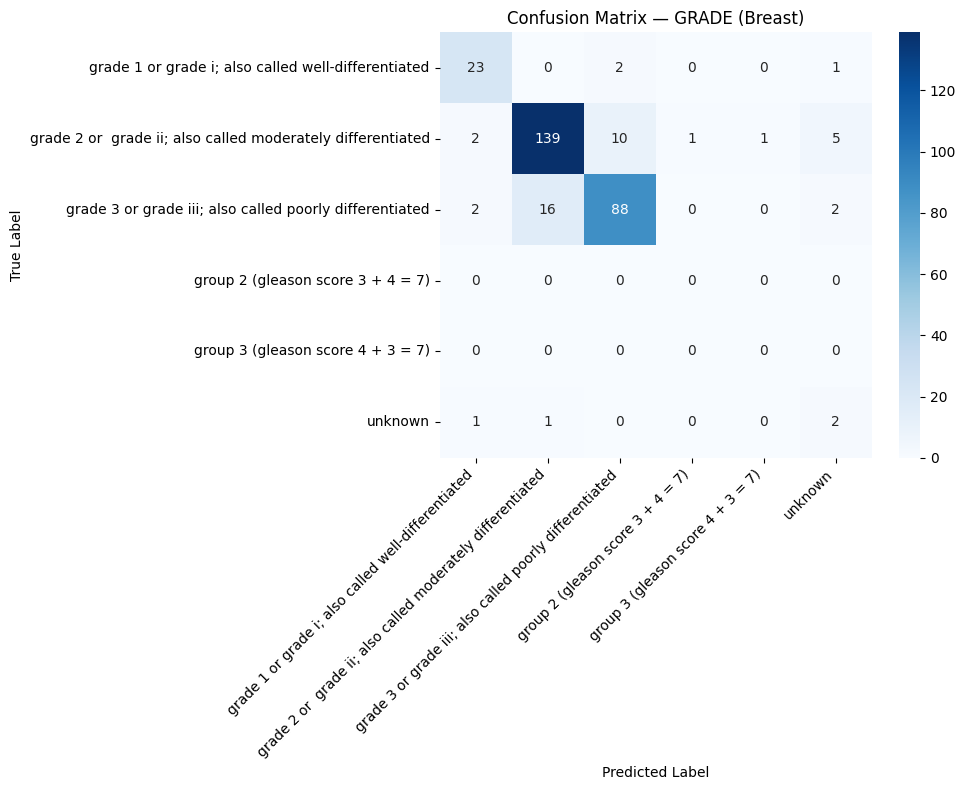


--- 📂 Category: MORP ---
📊 Classification Report:
                                                               precision    recall  f1-score   support

                                 carcinoma of no special type       0.00      0.00      0.00         1
                      carcinoma with apocrine differentiation       0.00      0.00      0.00         2
                carcinoma with neuroendocrine differentiation       0.00      0.00      0.00         0
                              ductal carcinoma in situ (dcis)       0.02      1.00      0.03         2
 infiltrating or invasive ductal carcinoma of no special type       0.99      0.53      0.69       253
infiltrating or invasive lobular carcinoma of no special type       0.90      0.79      0.84        24
                 invasive breast carcinoma of no special type       0.00      0.00      0.00         3
invasive ductal carcinoma with neuroendocrine differentiation       0.00      0.00      0.00         1
                     

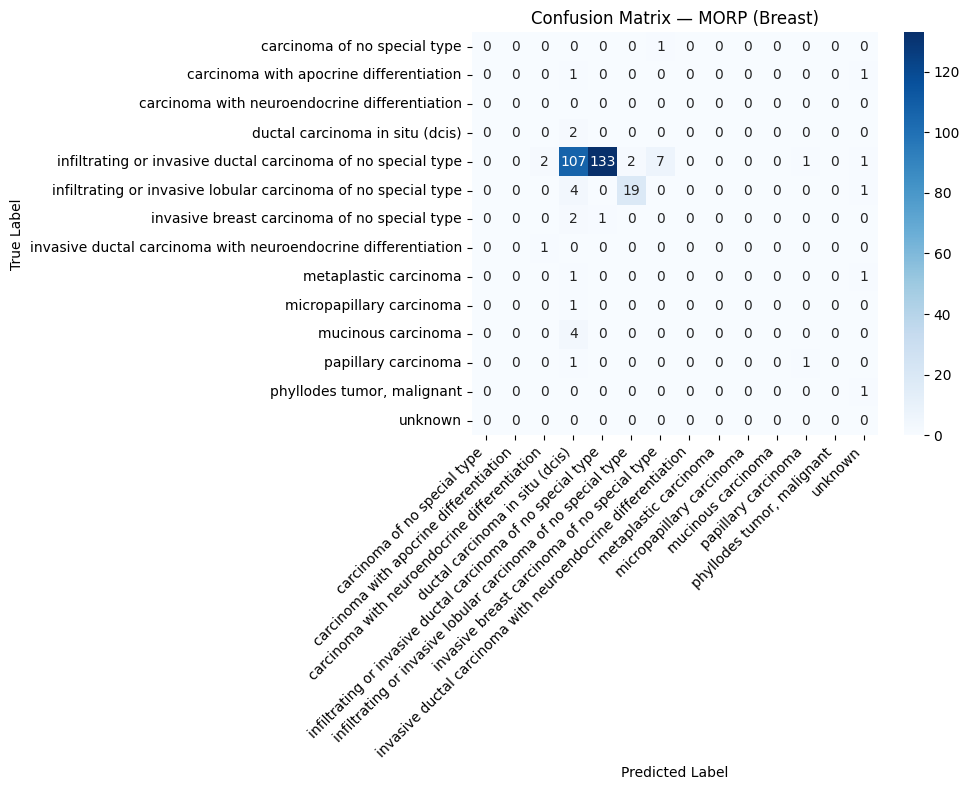


--- 📂 Category: STAGE ---
📊 Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           i       0.06      0.07      0.06        28
          ia       0.00      0.00      0.00         3
          ib       0.00      0.00      0.00         1
          ii       0.00      0.00      0.00         7
         iia       0.50      0.09      0.15        44
         iib       0.90      0.16      0.28        55
         iii       0.00      0.00      0.00         3
        iiia       0.80      0.09      0.16        45
        iiib       0.57      0.15      0.24        26
        iiic       0.80      0.17      0.29        23
          iv       0.67      0.08      0.14        51
     unknown       0.04      1.00      0.09         9

    accuracy                           0.14       296
   macro avg       0.33      0.14      0.11       296
weighted avg       0.60      0.14      0.18       296

🔍 Precision: 0.5973
🔍 Recal

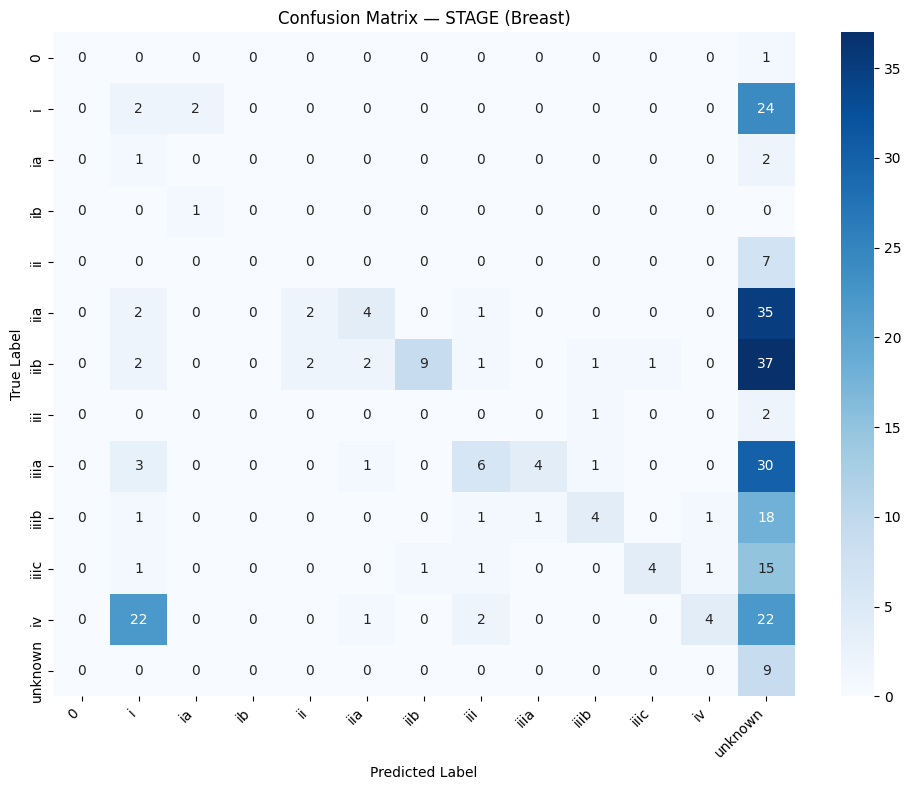


--- 📂 Category: T ---
📊 Classification Report:
              precision    recall  f1-score   support

          t1       0.71      0.54      0.61        28
         t1a       0.00      0.00      0.00         2
         t1b       0.00      0.00      0.00         8
         t1c       0.00      0.00      0.00         7
          t2       0.85      0.58      0.69       117
          t3       0.54      0.71      0.61        38
          t4       0.16      0.24      0.19        17
         t4a       0.00      0.00      0.00         1
         t4b       0.00      0.00      0.00        43
         t4c       0.00      0.00      0.00         3
         t4d       0.00      0.00      0.00         8
         tis       0.00      0.00      0.00         3
     unknown       0.17      1.00      0.30        21

    accuracy                           0.46       296
   macro avg       0.19      0.24      0.18       296
weighted avg       0.49      0.46      0.44       296

🔍 Precision: 0.4945
🔍 Recall:  

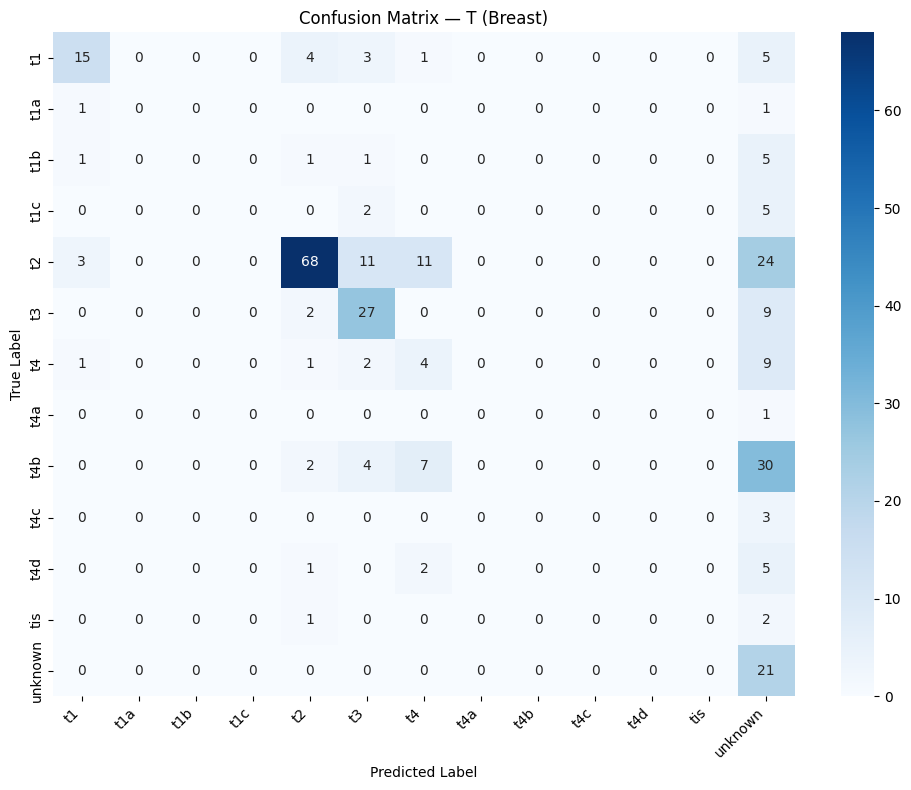


--- 📂 Category: N ---
📊 Classification Report:
              precision    recall  f1-score   support

          n0       0.99      0.76      0.86        91
          n1       0.84      0.81      0.83       111
          n2       0.57      0.69      0.62        42
          n3       0.61      1.00      0.76        30
          nx       0.00      0.00      0.00         2
     unknown       0.84      0.80      0.82        20

    accuracy                           0.79       296
   macro avg       0.64      0.68      0.65       296
weighted avg       0.82      0.79      0.79       296

🔍 Precision: 0.8181
🔍 Recall:    0.7905
🔍 F1-score:  0.7941


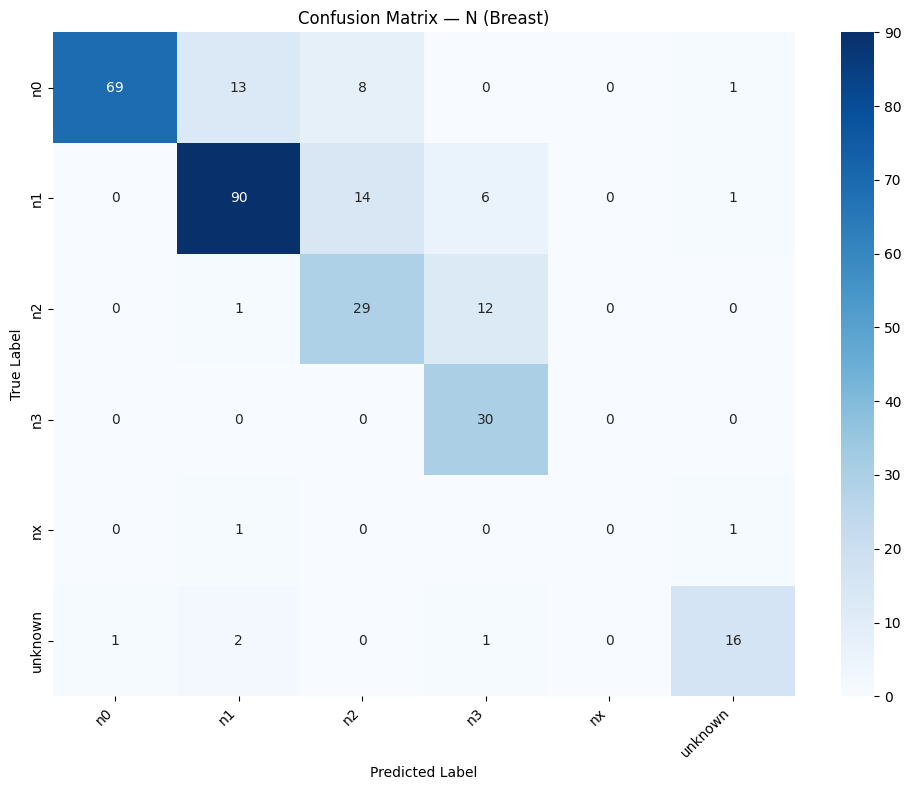


--- 📂 Category: M ---
📊 Classification Report:
              precision    recall  f1-score   support

          m0       0.68      0.81      0.74       154
          m1       0.66      0.91      0.77        45
          mx       0.53      0.22      0.31        82
     unknown       0.81      0.87      0.84        15

    accuracy                           0.67       296
   macro avg       0.67      0.70      0.66       296
weighted avg       0.64      0.67      0.63       296

🔍 Precision: 0.6418
🔍 Recall:    0.6655
🔍 F1-score:  0.6298


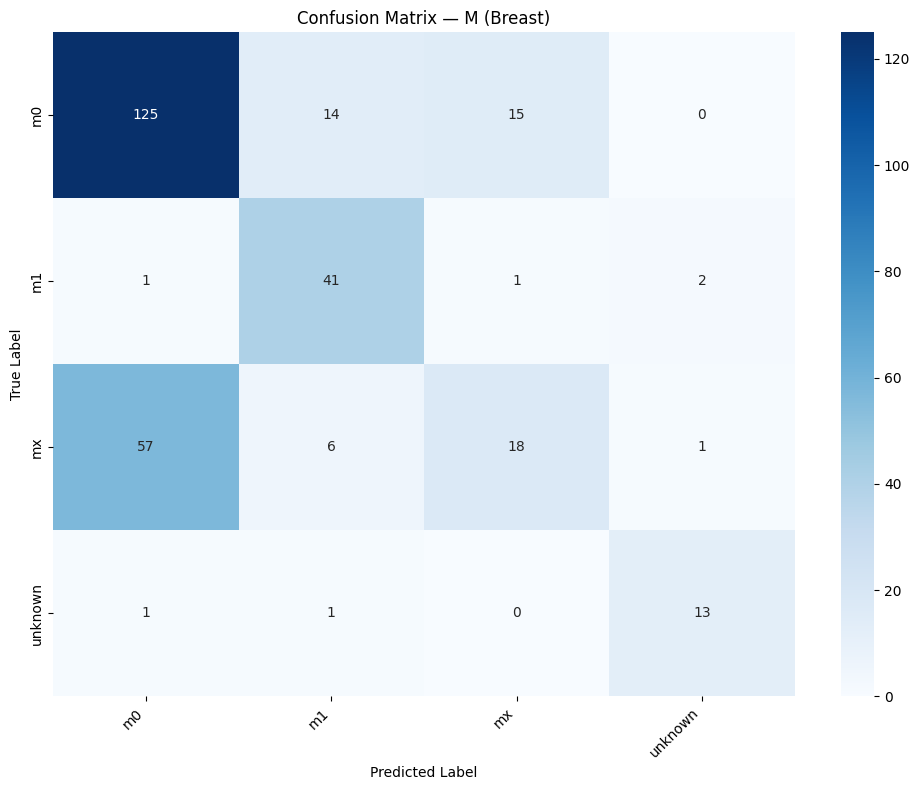


--- 📂 Category: LATER ---
📊 Classification Report:
                       precision    recall  f1-score   support

bilateral involvement       0.00      0.00      0.00         0
                 left       0.56      0.42      0.48       153
                right       1.00      0.01      0.03       136
              unknown       0.00      0.00      0.00         7

             accuracy                           0.23       296
            macro avg       0.39      0.11      0.13       296
         weighted avg       0.75      0.23      0.26       296

🔍 Precision: 0.7491
🔍 Recall:    0.2264
🔍 F1-score:  0.2631


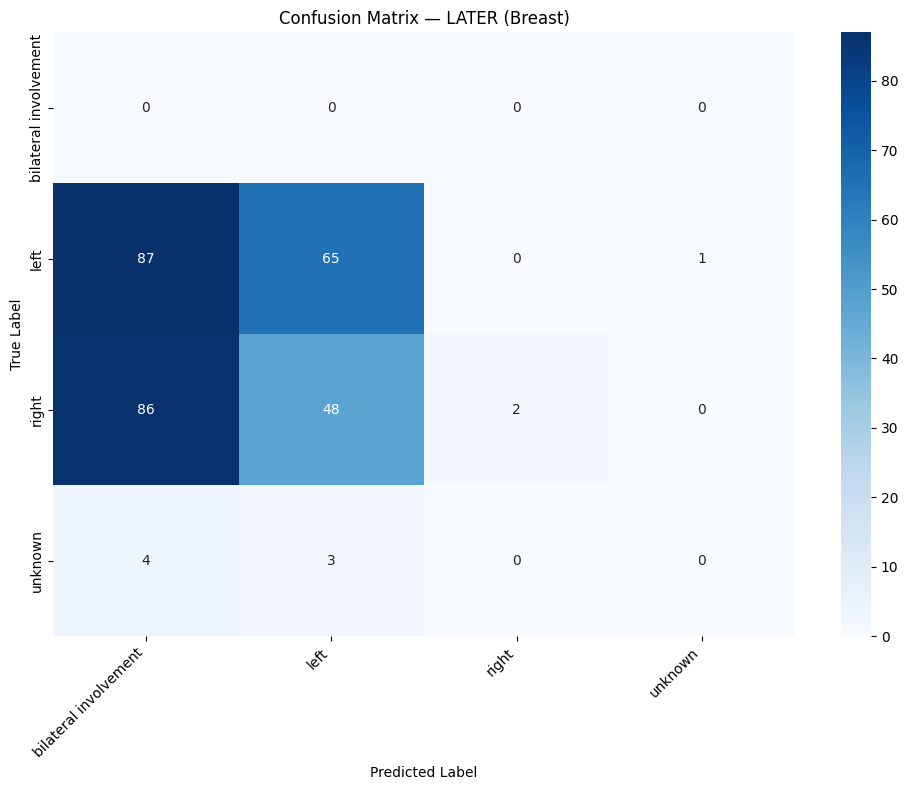



📌 Evaluating Site: COLORECTAL

--- 📂 Category: GRADE ---
📊 Classification Report:
                                                             precision    recall  f1-score   support

        grade 1 or grade i; also called well-differentiated       0.07      0.38      0.12         8
grade 2 or  grade ii; also called moderately differentiated       0.60      0.08      0.14        76
    grade 3 or grade iii; also called poorly differentiated       0.00      0.00      0.00         7
                                                    unknown       0.00      0.00      0.00         0

                                                   accuracy                           0.10        91
                                                  macro avg       0.17      0.11      0.07        91
                                               weighted avg       0.51      0.10      0.13        91

🔍 Precision: 0.5077
🔍 Recall:    0.0989
🔍 F1-score:  0.1275


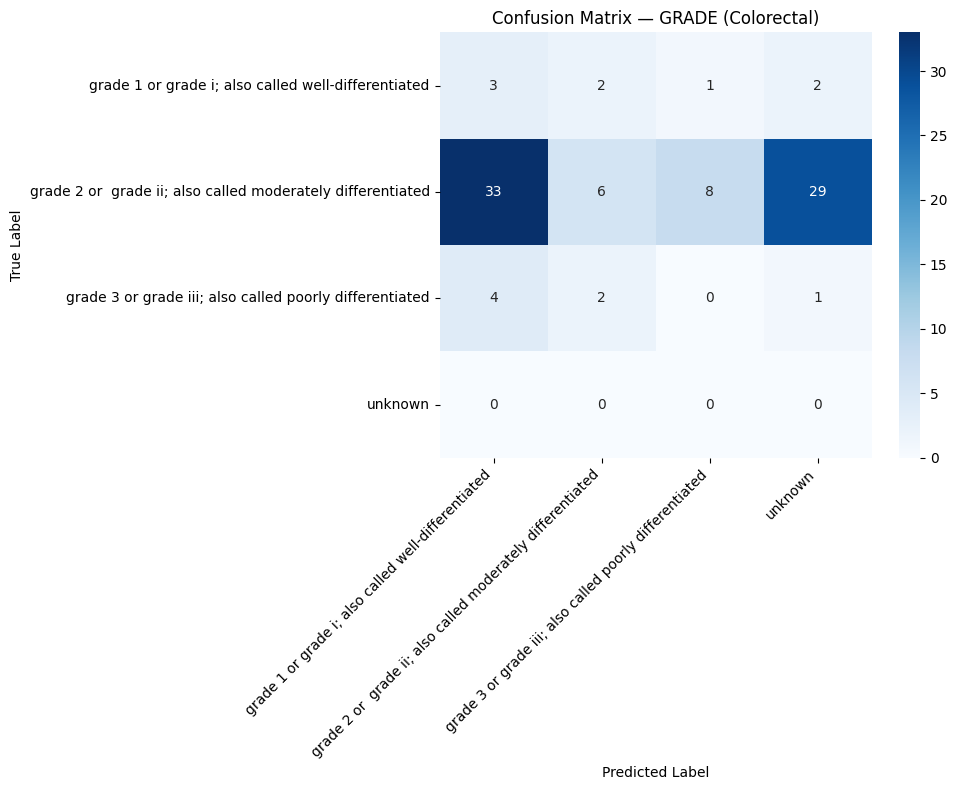


--- 📂 Category: MORP ---
📊 Classification Report:
                                                               precision    recall  f1-score   support

                            adenocarcinoma of no special type       0.00      0.00      0.00        85
                carcinoma with neuroendocrine differentiation       0.00      0.00      0.00         0
 infiltrating or invasive ductal carcinoma of no special type       0.00      0.00      0.00         0
infiltrating or invasive lobular carcinoma of no special type       0.00      0.00      0.00         0
                                      mucinous adenocarcinoma       0.75      0.60      0.67         5
                                   signet ring cell carcinoma       0.25      1.00      0.40         1
                                                      unknown       0.00      0.00      0.00         0

                                                     accuracy                           0.04        91
                    

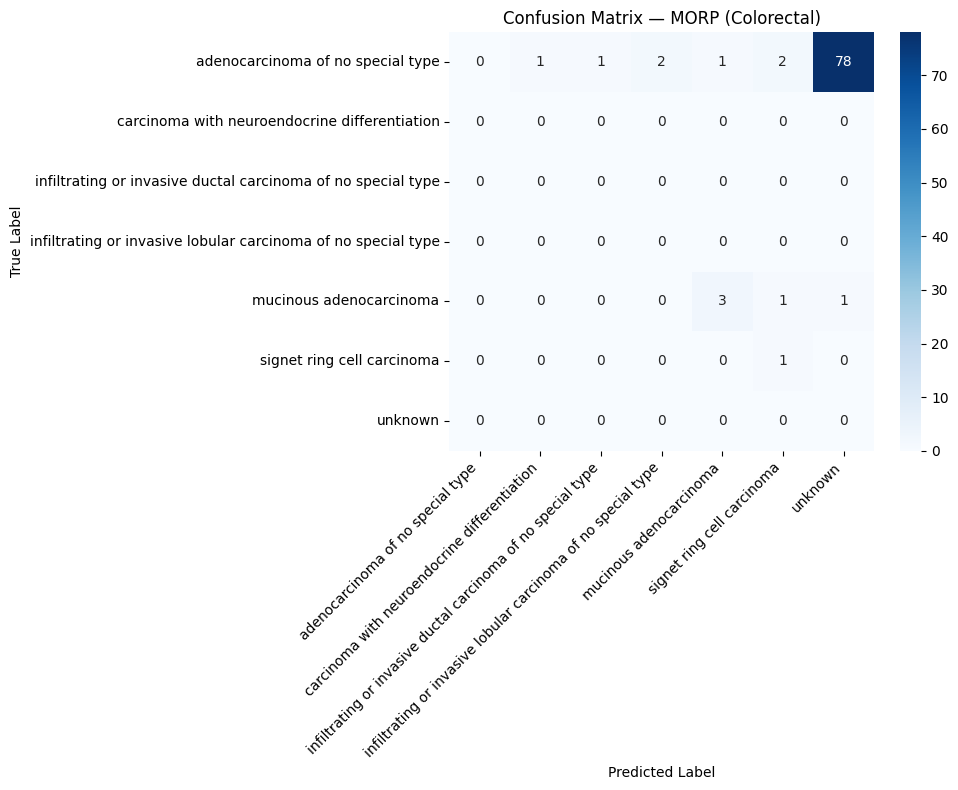


--- 📂 Category: STAGE ---
📊 Classification Report:
              precision    recall  f1-score   support

           i       0.09      0.60      0.16         5
          ia       0.00      0.00      0.00         0
          ib       1.00      1.00      1.00         2
          ii       0.62      0.83      0.71         6
         iia       0.75      1.00      0.86         6
         iib       0.33      0.33      0.33         3
         iii       0.25      0.50      0.33         4
        iiia       0.00      0.00      0.00         1
        iiib       1.00      0.82      0.90        11
        iiic       0.00      0.00      0.00         2
          iv       1.00      0.05      0.10        39
         iva       0.00      0.00      0.00         3
     unknown       0.44      0.89      0.59         9

    accuracy                           0.42        91
   macro avg       0.42      0.46      0.38        91
weighted avg       0.73      0.42      0.37        91

🔍 Precision: 0.7332
🔍 Recal

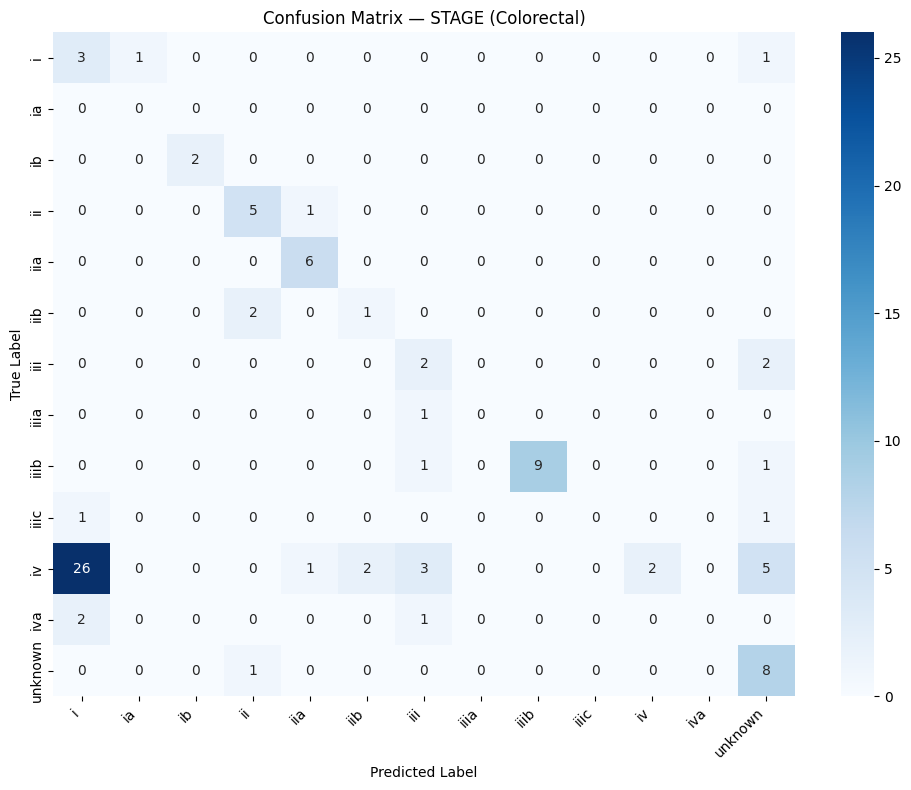


--- 📂 Category: T ---
📊 Classification Report:
              precision    recall  f1-score   support

          t1       1.00      1.00      1.00         2
          t2       0.86      0.50      0.63        12
          t3       0.86      0.65      0.74        37
          t4       0.29      0.12      0.17        16
     unknown       0.43      0.83      0.56        24

    accuracy                           0.59        91
   macro avg       0.69      0.62      0.62        91
weighted avg       0.65      0.59      0.58        91

🔍 Precision: 0.6460
🔍 Recall:    0.5934
🔍 F1-score:  0.5847


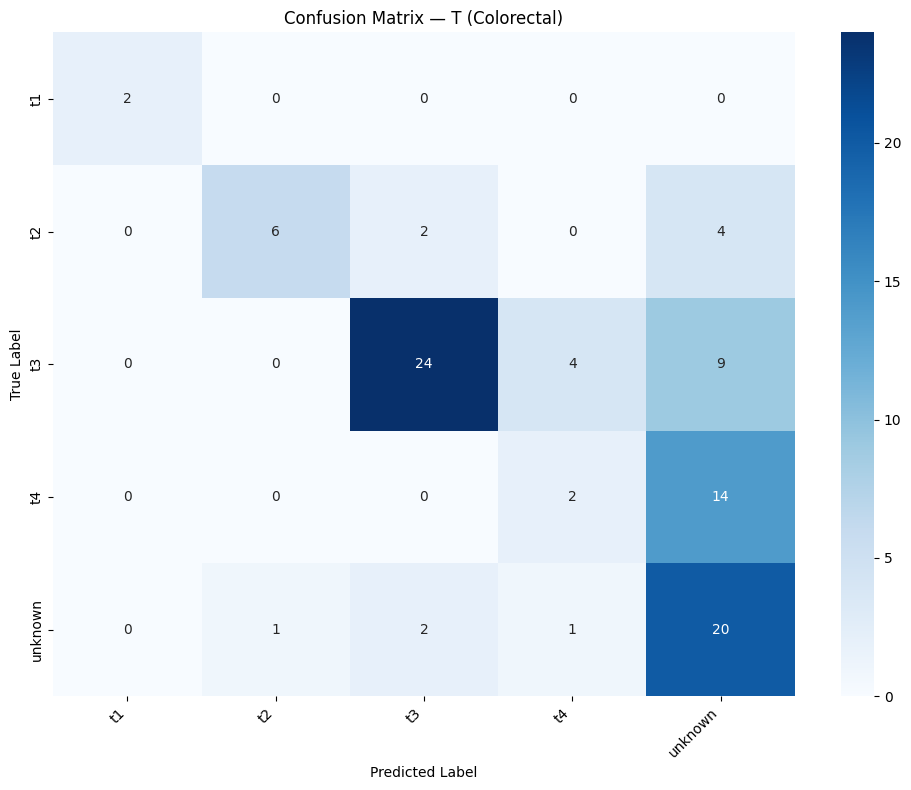


--- 📂 Category: N ---
📊 Classification Report:
              precision    recall  f1-score   support

          n0       0.96      0.79      0.86        28
          n1       0.72      0.75      0.73        24
         n1c       0.00      0.00      0.00         1
          n2       0.57      0.89      0.70         9
         n2a       0.00      0.00      0.00         1
         n2b       0.00      0.00      0.00         1
          nx       0.00      0.00      0.00         2
     unknown       0.69      0.80      0.74        25

    accuracy                           0.75        91
   macro avg       0.37      0.40      0.38        91
weighted avg       0.73      0.75      0.73        91

🔍 Precision: 0.7302
🔍 Recall:    0.7473
🔍 F1-score:  0.7315


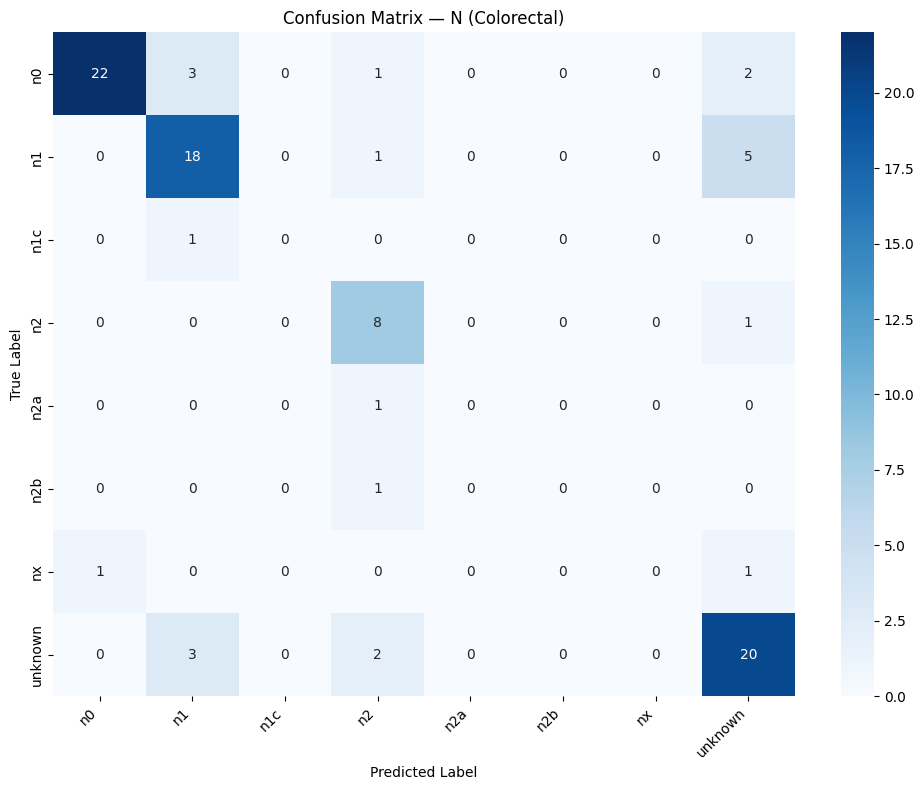


--- 📂 Category: M ---
📊 Classification Report:
              precision    recall  f1-score   support

          m0       0.56      0.85      0.68        27
          m1       0.88      0.18      0.30        39
          mx       0.79      0.50      0.61        22
     unknown       0.11      1.00      0.19         3

    accuracy                           0.48        91
   macro avg       0.58      0.63      0.44        91
weighted avg       0.73      0.48      0.48        91

🔍 Precision: 0.7349
🔍 Recall:    0.4835
🔍 F1-score:  0.4825


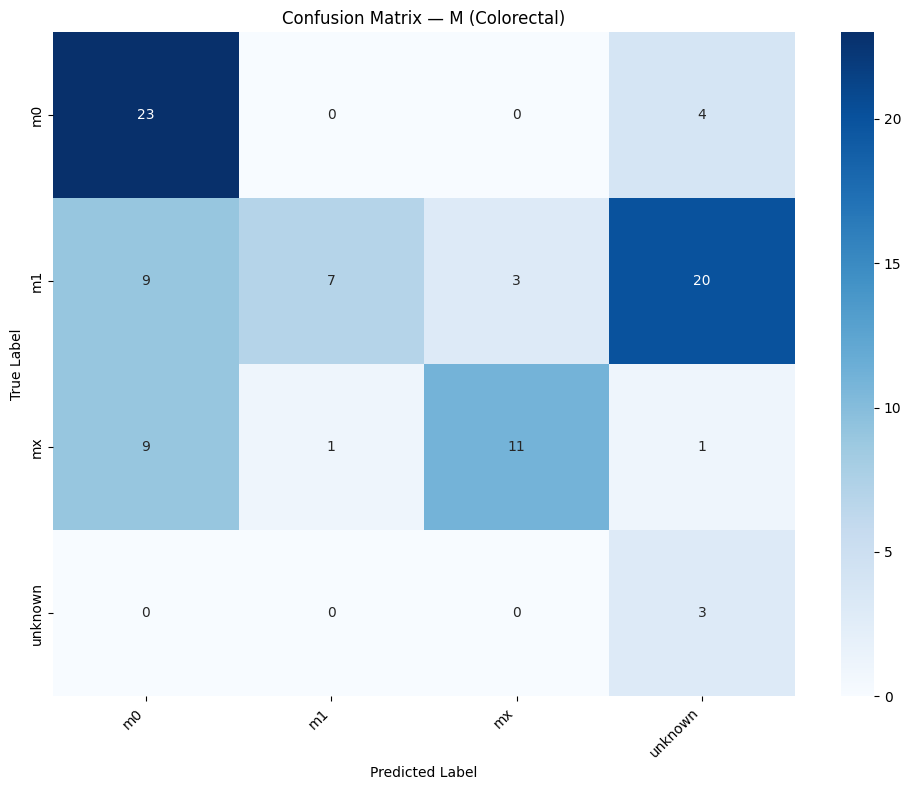


--- 📂 Category: LATER ---
📊 Classification Report:
                         precision    recall  f1-score   support

  bilateral involvement       0.02      1.00      0.04         1
                   left       0.78      0.38      0.52        65
                  right       0.43      0.17      0.24        18
right, transverse colon       0.00      0.00      0.00         6
                unknown       0.00      0.00      0.00         1

               accuracy                           0.32        91
              macro avg       0.25      0.31      0.16        91
           weighted avg       0.64      0.32      0.42        91

🔍 Precision: 0.6430
🔍 Recall:    0.3187
🔍 F1-score:  0.4161


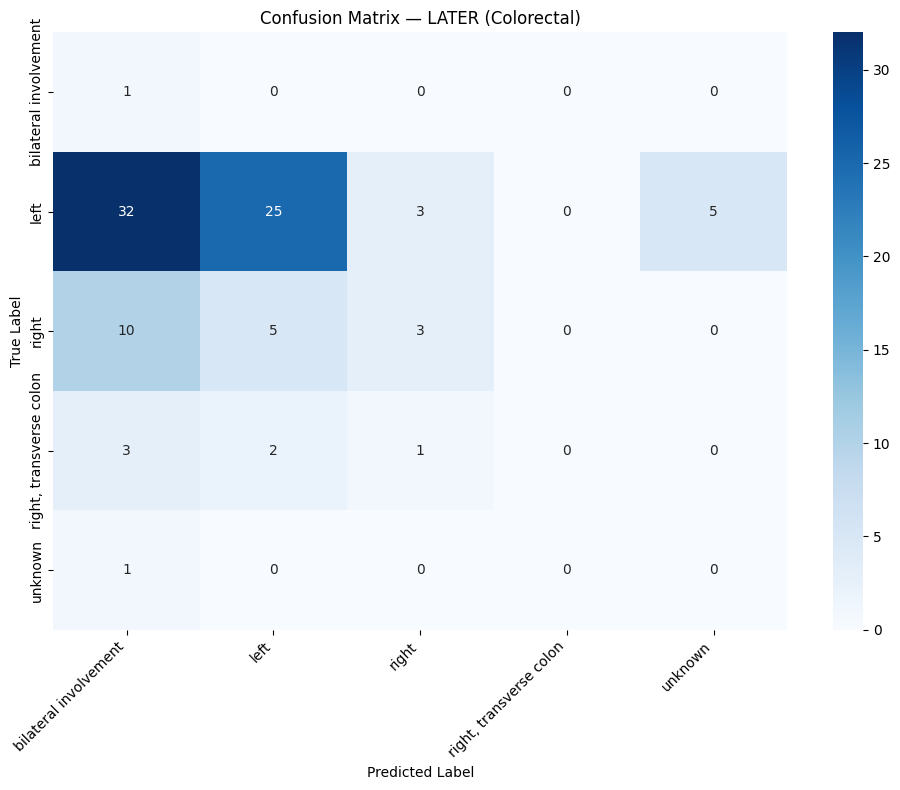



📌 Evaluating Site: THYROID

--- 📂 Category: GRADE ---
📊 Classification Report:
                                                             precision    recall  f1-score   support

        grade 1 or grade i; also called well-differentiated       0.00      0.00      0.00         0
grade 2 or  grade ii; also called moderately differentiated       0.00      0.00      0.00         0
    grade 3 or grade iii; also called poorly differentiated       0.00      0.00      0.00         0
                                             not applicable       0.00      0.00      0.00         1
                                                    unknown       0.99      0.87      0.93        85

                                                   accuracy                           0.86        86
                                                  macro avg       0.20      0.17      0.18        86
                                               weighted avg       0.98      0.86      0.91        86

🔍 Preci

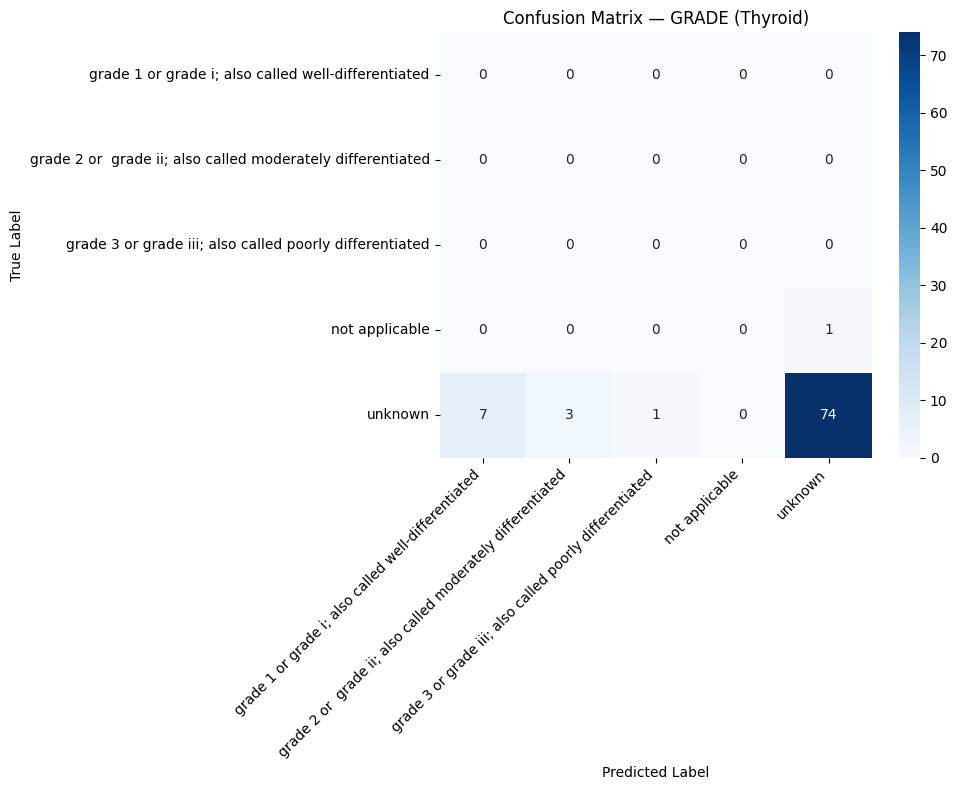


--- 📂 Category: MORP ---
📊 Classification Report:
                                                              precision    recall  f1-score   support

               carcinoma with neuroendocrine differentiation       0.00      0.00      0.00         0
                                  carcinoma, anaplastic, nos       0.00      0.00      0.00         1
                                        follicular carcinoma       0.00      0.00      0.00         4
infiltrating or invasive ductal carcinoma of no special type       0.00      0.00      0.00         0
                                         medullary carcinoma       0.00      0.00      0.00         3
                                         papillary carcinoma       1.00      0.88      0.94        78
                                                     unknown       0.00      0.00      0.00         0

                                                    accuracy                           0.80        86
                             

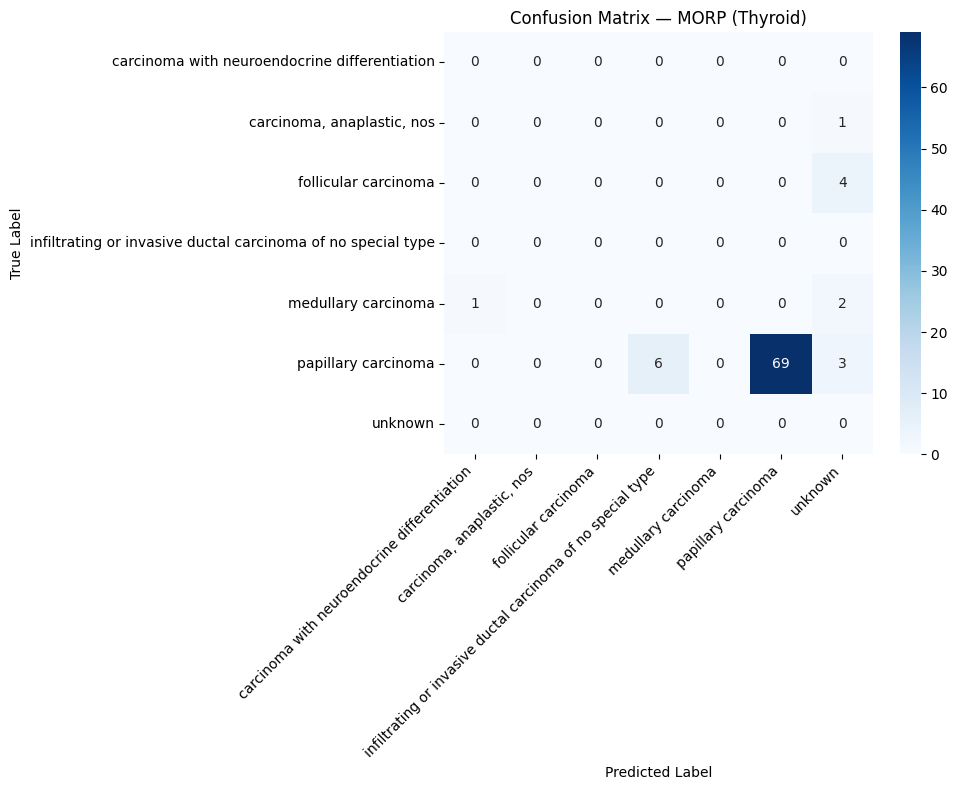


--- 📂 Category: STAGE ---
📊 Classification Report:
              precision    recall  f1-score   support

           i       0.21      0.05      0.08        60
          ii       1.00      0.50      0.67         4
         iii       0.00      0.00      0.00         4
          iv       0.00      0.00      0.00        12
     unknown       0.09      1.00      0.16         6

    accuracy                           0.13        86
   macro avg       0.26      0.31      0.18        86
weighted avg       0.20      0.13      0.10        86

🔍 Precision: 0.2020
🔍 Recall:    0.1279
🔍 F1-score:  0.0986


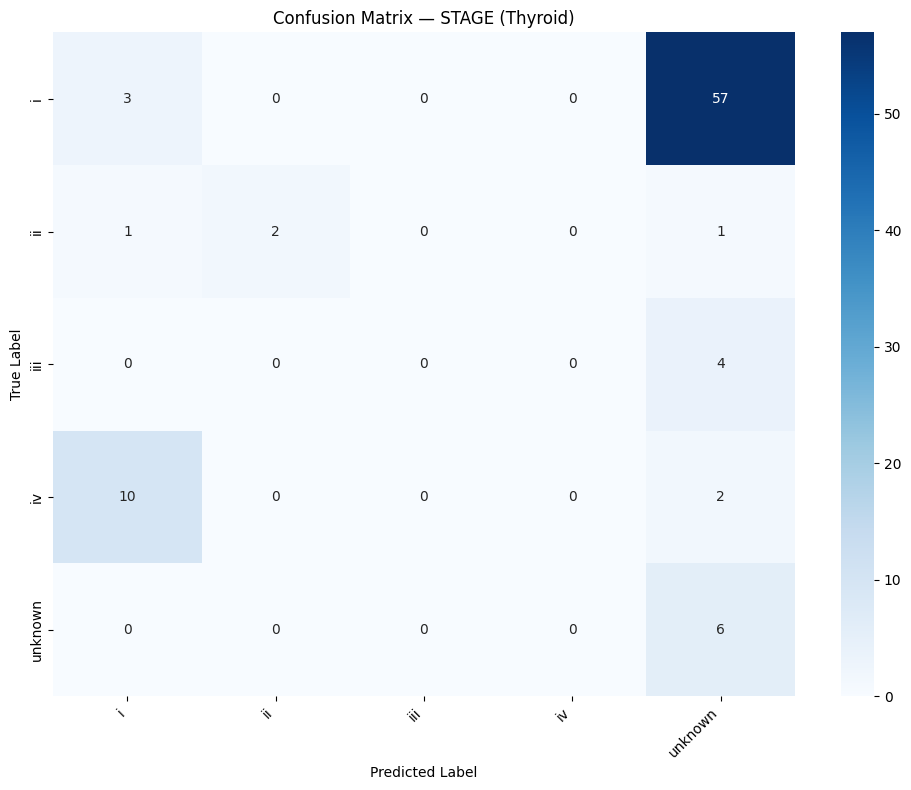


--- 📂 Category: T ---
📊 Classification Report:
              precision    recall  f1-score   support

         t1a       0.00      0.00      0.00         5
         t1b       0.00      0.00      0.00         1
          t2       0.00      0.00      0.00         3
          t3       1.00      0.30      0.46        10
         t3a       0.00      0.00      0.00         1
          t4       0.11      0.33      0.16         6
     unknown       0.74      0.75      0.74        60

    accuracy                           0.58        86
   macro avg       0.26      0.20      0.20        86
weighted avg       0.64      0.58      0.58        86

🔍 Precision: 0.6383
🔍 Recall:    0.5814
🔍 F1-score:  0.5838


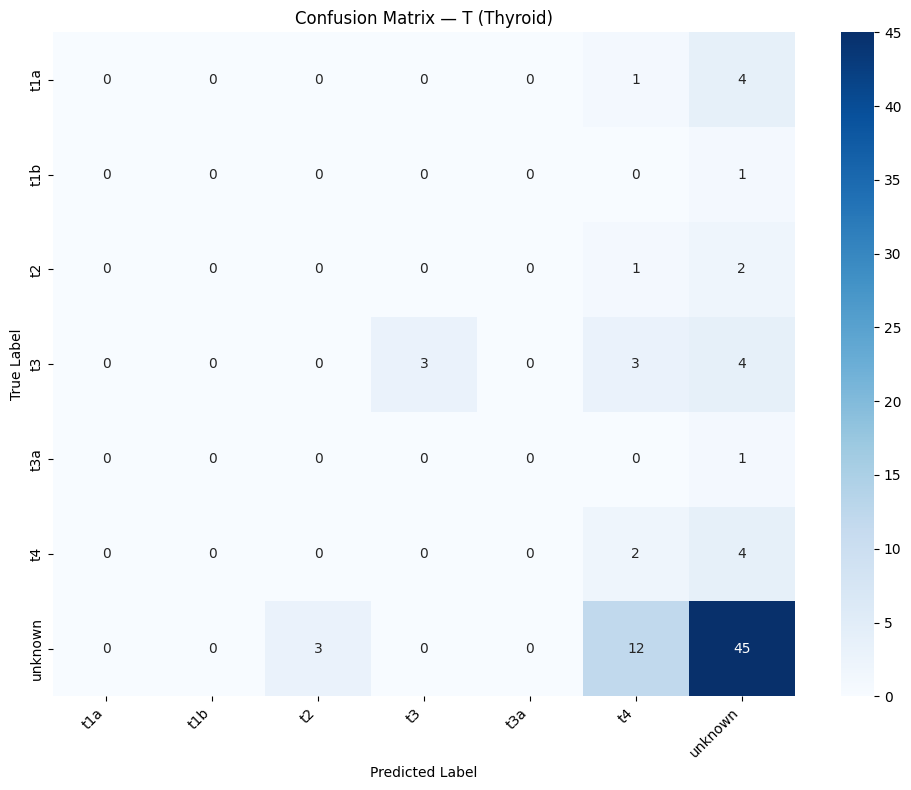


--- 📂 Category: N ---
📊 Classification Report:
              precision    recall  f1-score   support

          n0       1.00      0.67      0.80         3
          n1       0.09      0.05      0.06        22
         n1a       0.00      0.00      0.00         4
         n1b       0.00      0.00      0.00         5
          n2       0.00      0.00      0.00         0
          n4       0.00      0.00      0.00         1
          nx       0.00      0.00      0.00         6
     unknown       0.58      0.93      0.72        45

    accuracy                           0.52        86
   macro avg       0.21      0.21      0.20        86
weighted avg       0.36      0.52      0.42        86

🔍 Precision: 0.3634
🔍 Recall:    0.5233
🔍 F1-score:  0.4191


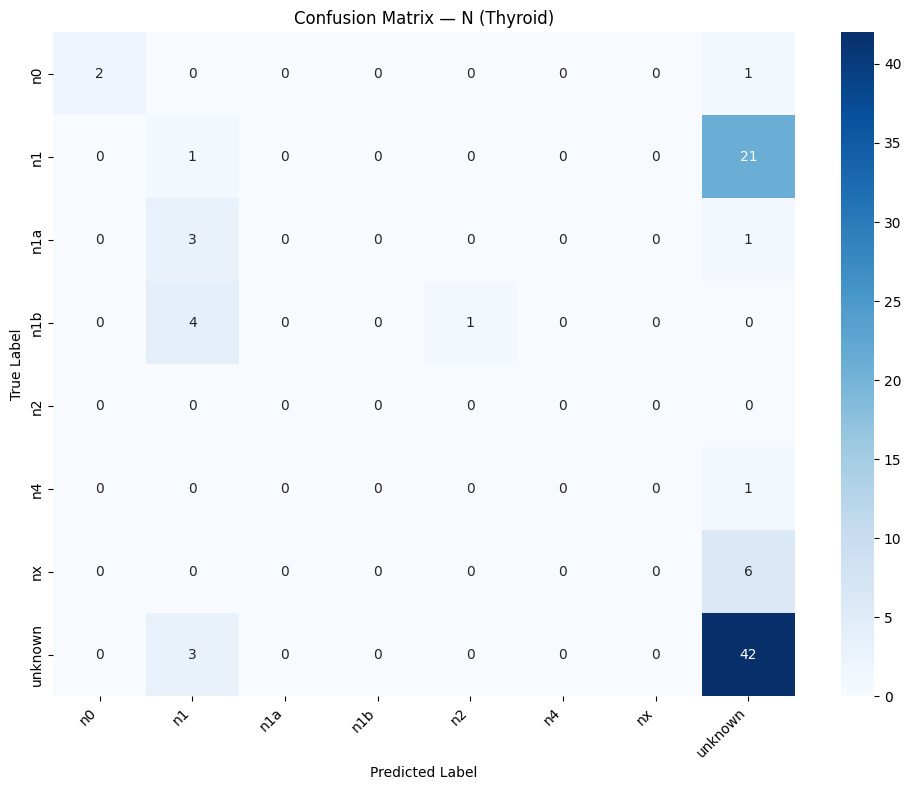


--- 📂 Category: M ---
📊 Classification Report:
              precision    recall  f1-score   support

          m0       0.75      1.00      0.86         3
          m1       0.50      0.11      0.18         9
          mx       1.00      0.58      0.73        19
     unknown       0.77      0.96      0.85        55

    accuracy                           0.79        86
   macro avg       0.75      0.66      0.66        86
weighted avg       0.79      0.79      0.76        86

🔍 Precision: 0.7907
🔍 Recall:    0.7907
🔍 F1-score:  0.7576


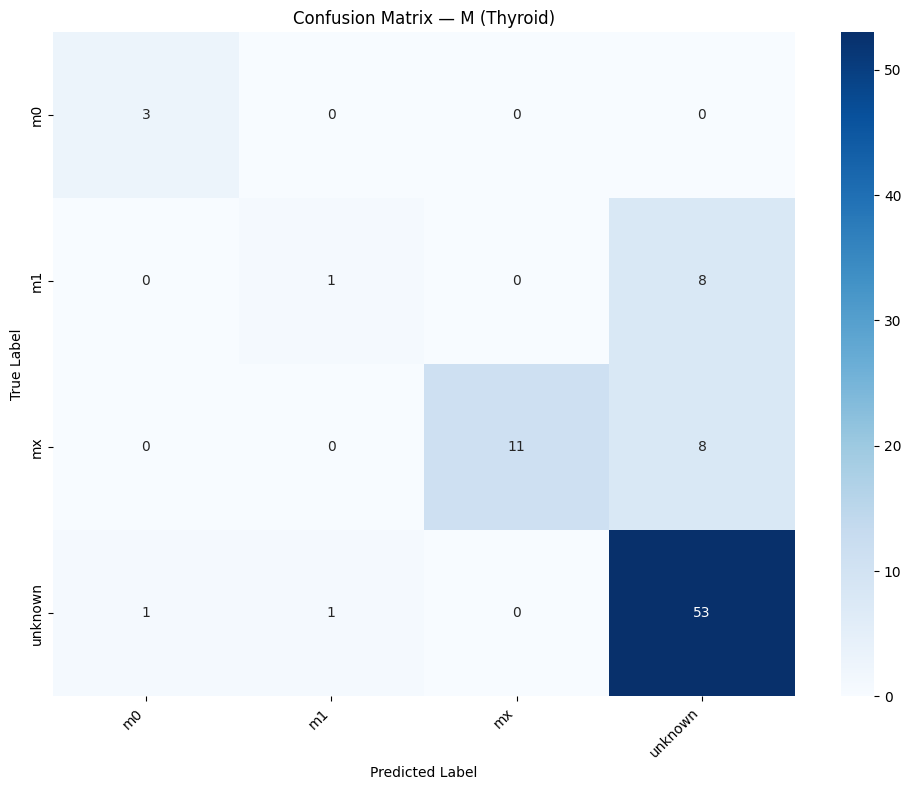


--- 📂 Category: LATER ---
📊 Classification Report:
                       precision    recall  f1-score   support

bilateral involvement       0.04      0.50      0.07         2
                 left       0.17      0.62      0.27         8
              midline       0.00      0.00      0.00         0
                right       0.30      0.25      0.27        12
              unknown       0.89      0.27      0.41        64

             accuracy                           0.30        86
            macro avg       0.28      0.33      0.20        86
         weighted avg       0.72      0.30      0.37        86

🔍 Precision: 0.7246
🔍 Recall:    0.3023
🔍 F1-score:  0.3697


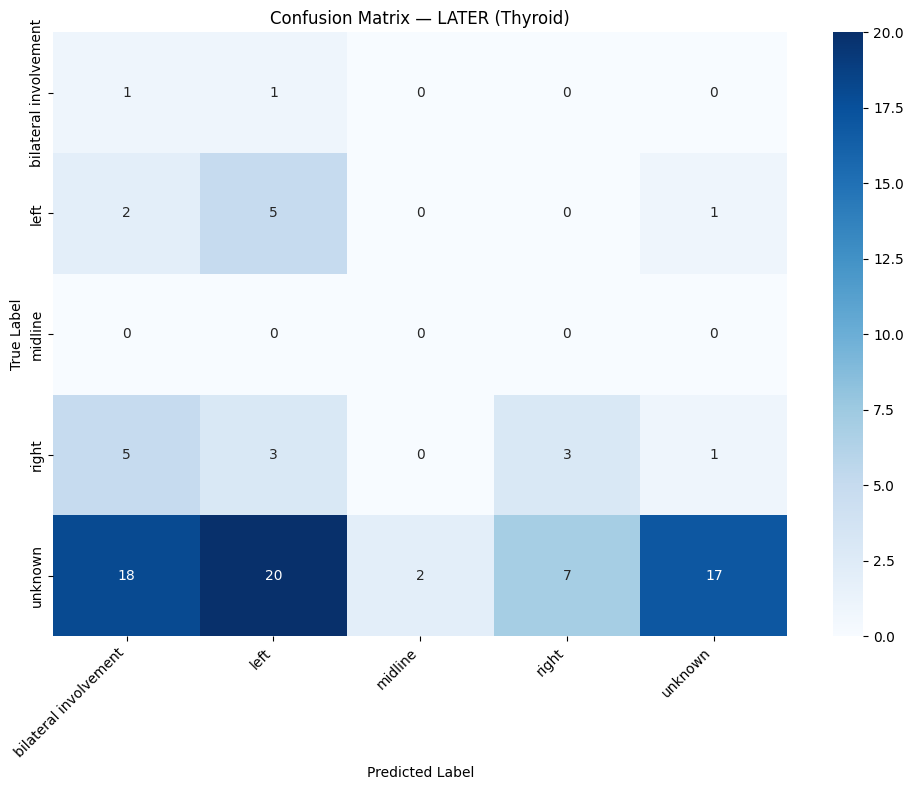



📌 Evaluating Site: PROSTATE

--- 📂 Category: GRADE ---
📊 Classification Report:
                                                             precision    recall  f1-score   support

        grade 1 or grade i; also called well-differentiated       0.00      0.00      0.00         0
grade 2 or  grade ii; also called moderately differentiated       0.00      0.00      0.00         0
    grade 3 or grade iii; also called poorly differentiated       0.00      0.00      0.00         0
                          group 1 (gleason score 3 + 3 = 6)       0.80      0.50      0.62        16
                          group 2 (gleason score 3 + 4 = 7)       1.00      0.46      0.63        13
                          group 3 (gleason score 4 + 3 = 7)       1.00      0.43      0.60         7
                          group 4 (gleason score 3 + 5 = 8)       1.00      0.50      0.67         2
                          group 4 (gleason score 4 + 4 = 8)       0.67      0.13      0.22        15
        

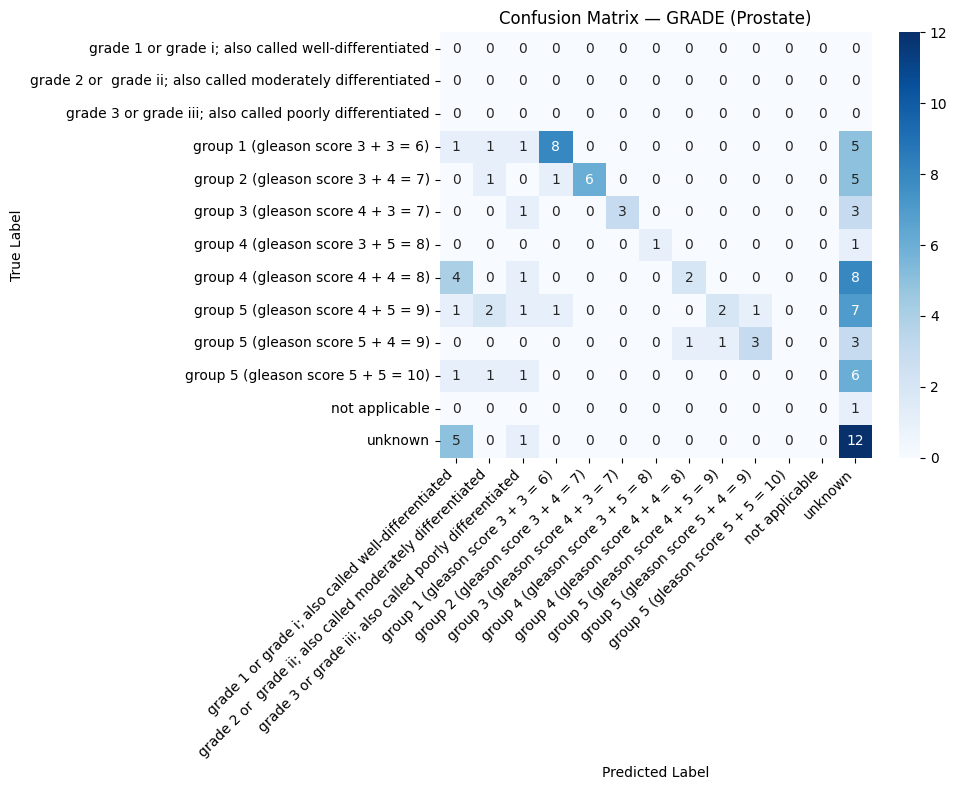


--- 📂 Category: MORP ---
📊 Classification Report:
                                                              precision    recall  f1-score   support

                                       acinar adenocarcinoma       0.95      0.20      0.33       101
               carcinoma with neuroendocrine differentiation       0.00      0.00      0.00         0
infiltrating or invasive ductal carcinoma of no special type       0.00      0.00      0.00         0
                                         papillary carcinoma       0.00      0.00      0.00         0
                                                     unknown       0.03      0.67      0.05         3

                                                    accuracy                           0.21       104
                                                   macro avg       0.20      0.17      0.08       104
                                                weighted avg       0.93      0.21      0.32       104

🔍 Precision: 0.9257
🔍 Recall

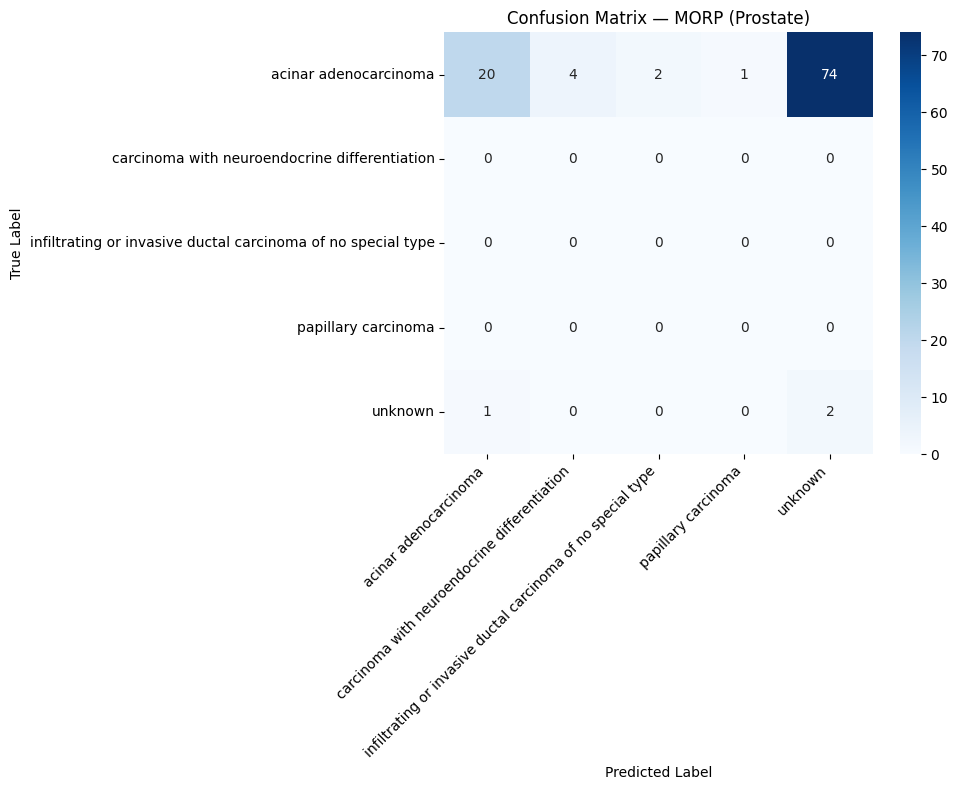


--- 📂 Category: STAGE ---
📊 Classification Report:
              precision    recall  f1-score   support

           i       0.02      0.33      0.04         3
          ii       0.00      0.00      0.00         0
          iv       0.00      0.00      0.00        38
         iva       0.00      0.00      0.00         1
     unknown       0.93      0.92      0.93        62

    accuracy                           0.56       104
   macro avg       0.19      0.25      0.19       104
weighted avg       0.56      0.56      0.55       104

🔍 Precision: 0.5577
🔍 Recall:    0.5577
🔍 F1-score:  0.5538


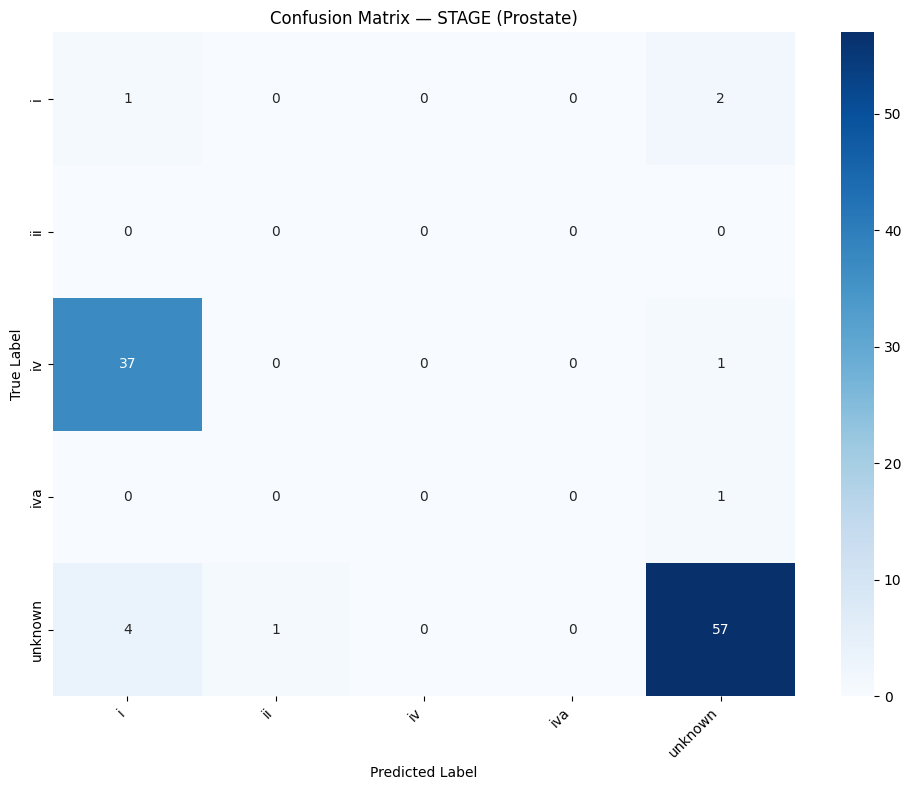


--- 📂 Category: T ---
📊 Classification Report:
              precision    recall  f1-score   support

          t1       0.00      0.00      0.00         1
         t1a       0.00      0.00      0.00        11
         t1b       0.00      0.00      0.00         4
         t1c       0.00      0.00      0.00        54
          t2       0.33      0.42      0.37        12
          t3       0.00      0.00      0.00         1
         t3a       0.00      0.00      0.00         1
         t3b       0.00      0.00      0.00         3
          t4       0.00      0.00      0.00         0
     unknown       0.20      0.94      0.32        17

    accuracy                           0.20       104
   macro avg       0.05      0.14      0.07       104
weighted avg       0.07      0.20      0.10       104

🔍 Precision: 0.0704
🔍 Recall:    0.2019
🔍 F1-score:  0.0956


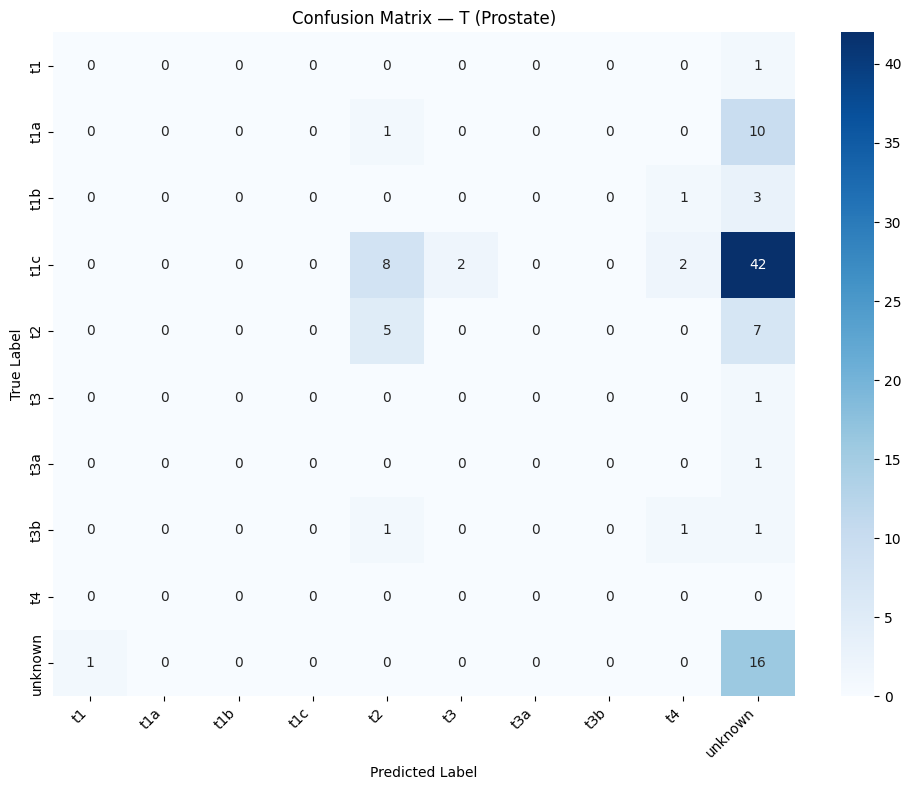


--- 📂 Category: N ---
📊 Classification Report:
              precision    recall  f1-score   support

          n0       0.50      0.86      0.63         7
          n1       0.50      0.75      0.60         4
          nx       0.00      0.00      0.00        75
     unknown       0.19      0.89      0.31        18

    accuracy                           0.24       104
   macro avg       0.30      0.62      0.38       104
weighted avg       0.09      0.24      0.12       104

🔍 Precision: 0.0851
🔍 Recall:    0.2404
🔍 F1-score:  0.1188


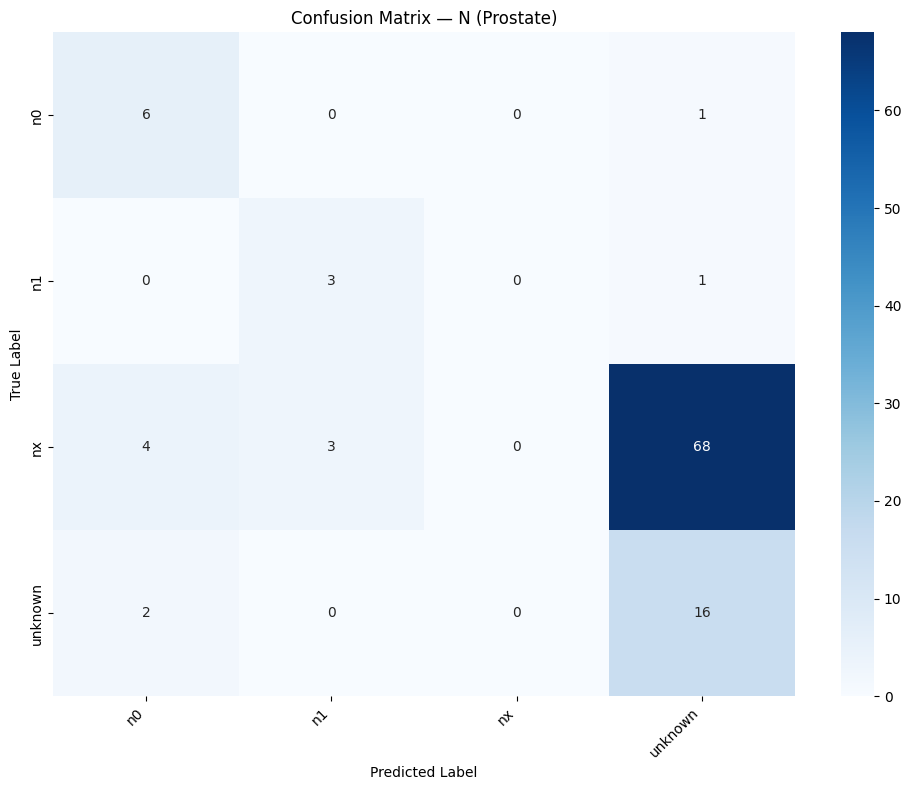


--- 📂 Category: M ---
📊 Classification Report:
              precision    recall  f1-score   support

          m0       0.31      0.71      0.43         7
          m1       0.00      0.00      0.00         1
         m1a       0.00      0.00      0.00         1
         m1b       0.00      0.00      0.00        10
         m1c       0.00      0.00      0.00         1
          mx       1.00      0.07      0.13        70
     unknown       0.16      0.86      0.27        14

    accuracy                           0.21       104
   macro avg       0.21      0.23      0.12       104
weighted avg       0.72      0.21      0.15       104

🔍 Precision: 0.7154
🔍 Recall:    0.2115
🔍 F1-score:  0.1549


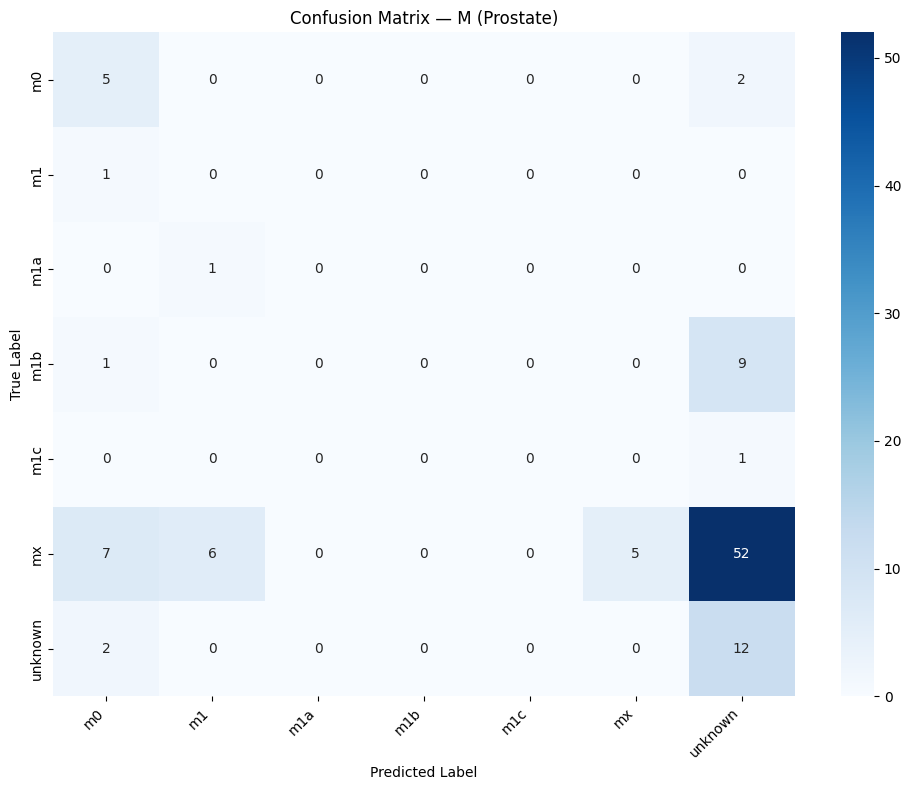


--- 📂 Category: LATER ---
📊 Classification Report:
                       precision    recall  f1-score   support

bilateral involvement       0.35      0.66      0.45        29
                 left       0.07      0.67      0.13         3
              midline       0.00      0.00      0.00         1
                right       0.00      0.00      0.00         3
              unknown       0.94      0.22      0.36        68

             accuracy                           0.35       104
            macro avg       0.27      0.31      0.19       104
         weighted avg       0.71      0.35      0.36       104

🔍 Precision: 0.7114
🔍 Recall:    0.3462
🔍 F1-score:  0.3635


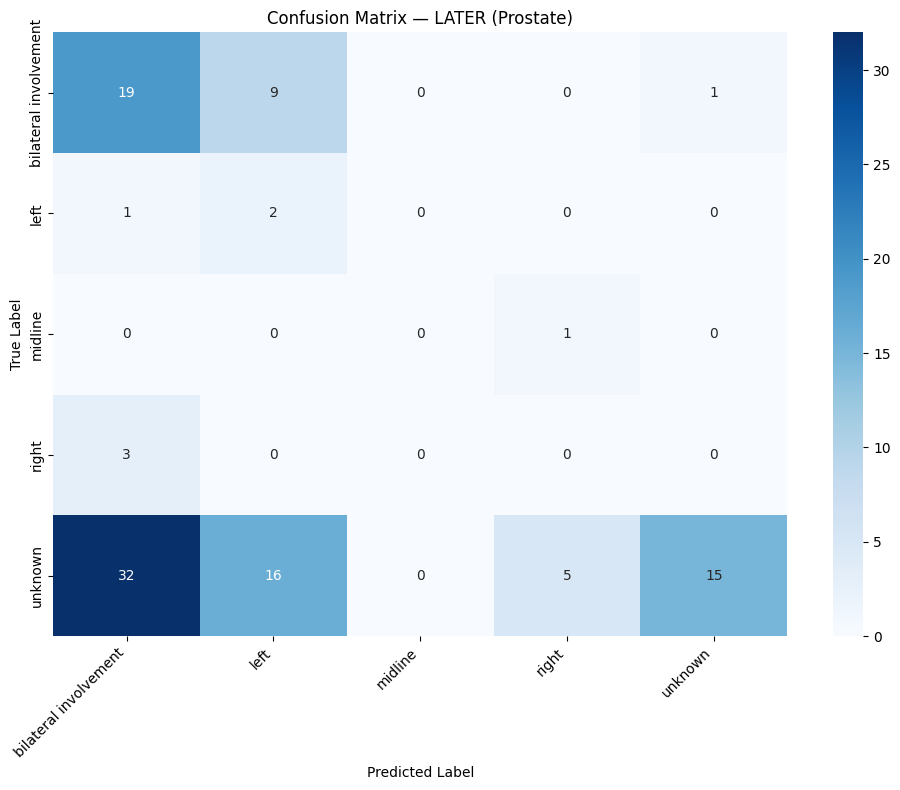



📌 Evaluating Site: RECTUM

--- 📂 Category: GRADE ---
📊 Classification Report:
                                                     precision    recall  f1-score   support

grade 1 or grade i; also called well-differentiated       0.00      0.00      0.00       0.0
                                grade ii (mod diff)       0.00      0.00      0.00       1.0

                                           accuracy                           0.00       1.0
                                          macro avg       0.00      0.00      0.00       1.0
                                       weighted avg       0.00      0.00      0.00       1.0

🔍 Precision: 0.0000
🔍 Recall:    0.0000
🔍 F1-score:  0.0000


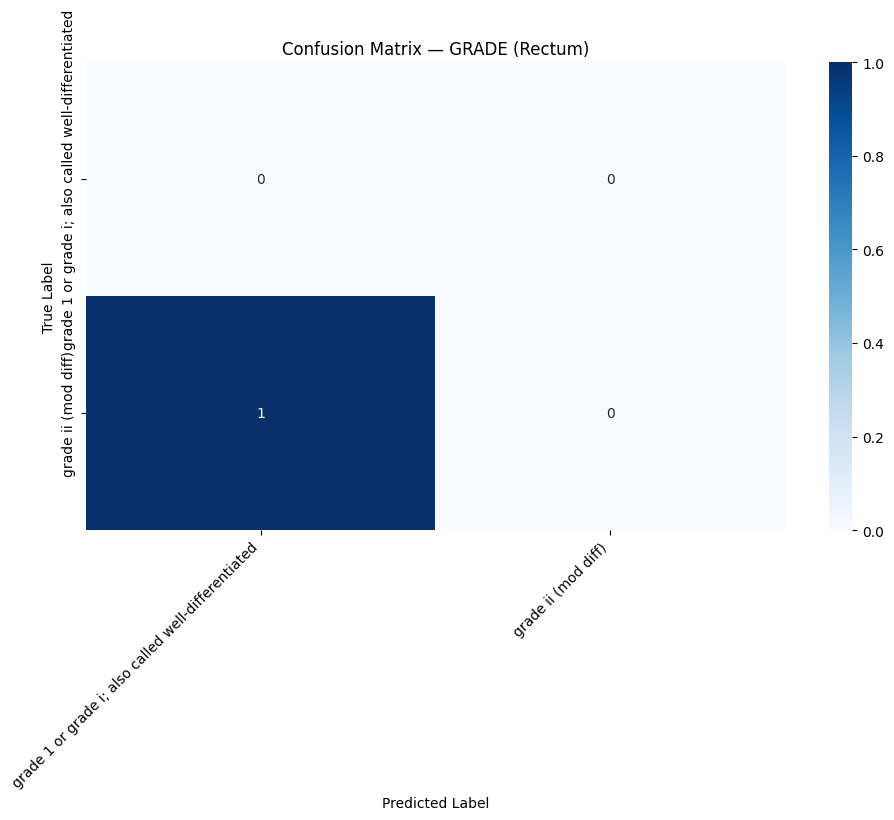


--- 📂 Category: MORP ---
⚠️ Only 'unknown' labels found. Skipping.

--- 📂 Category: STAGE ---
⚠️ Only 'unknown' labels found. Skipping.

--- 📂 Category: T ---
📊 Classification Report:
              precision    recall  f1-score   support

         tis       0.00      0.00      0.00       1.0
     unknown       0.00      0.00      0.00       0.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0

🔍 Precision: 0.0000
🔍 Recall:    0.0000
🔍 F1-score:  0.0000


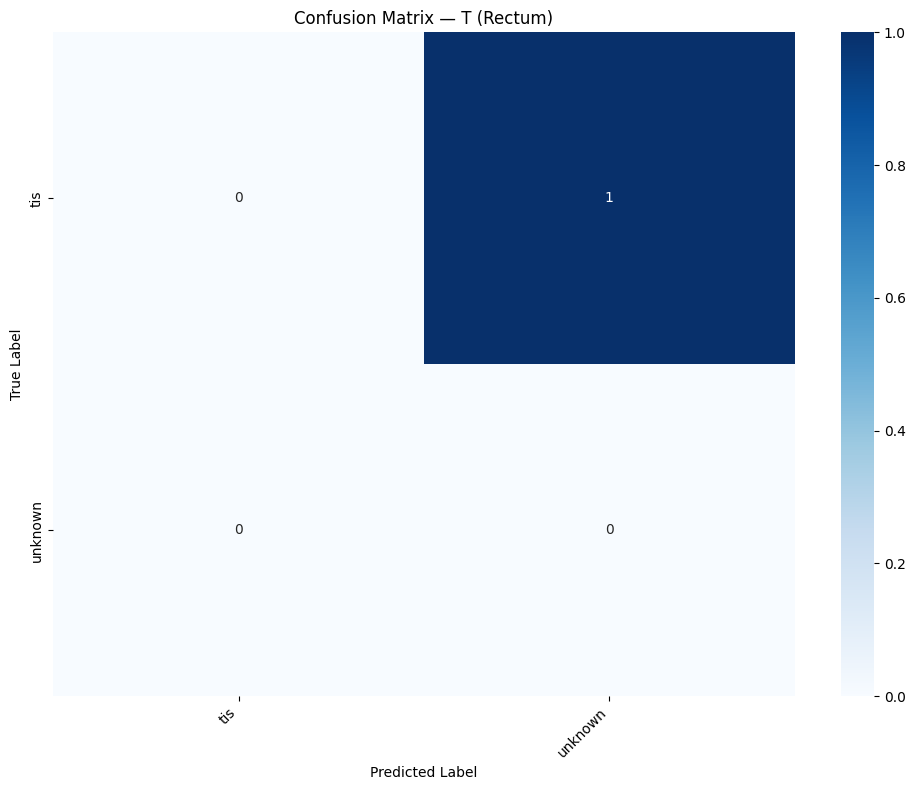


--- 📂 Category: N ---
📊 Classification Report:
              precision    recall  f1-score   support

          n1       0.00      0.00      0.00       0.0
          nx       0.00      0.00      0.00       1.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0

🔍 Precision: 0.0000
🔍 Recall:    0.0000
🔍 F1-score:  0.0000


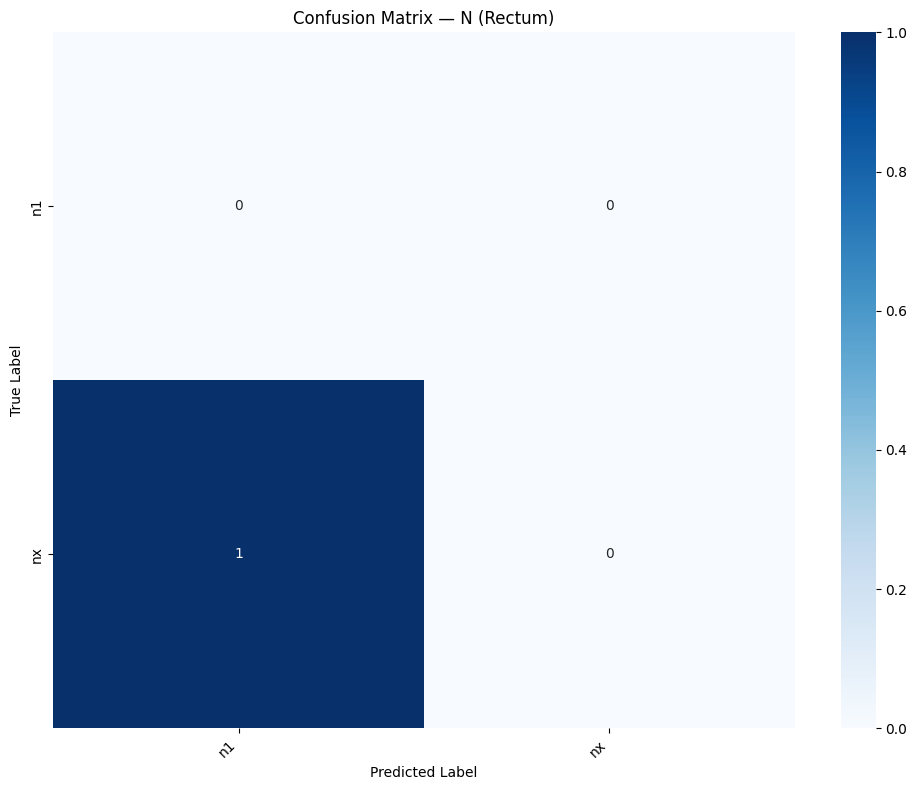


--- 📂 Category: M ---
📊 Classification Report:
              precision    recall  f1-score   support

          mx       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1

🔍 Precision: 1.0000
🔍 Recall:    1.0000
🔍 F1-score:  1.0000


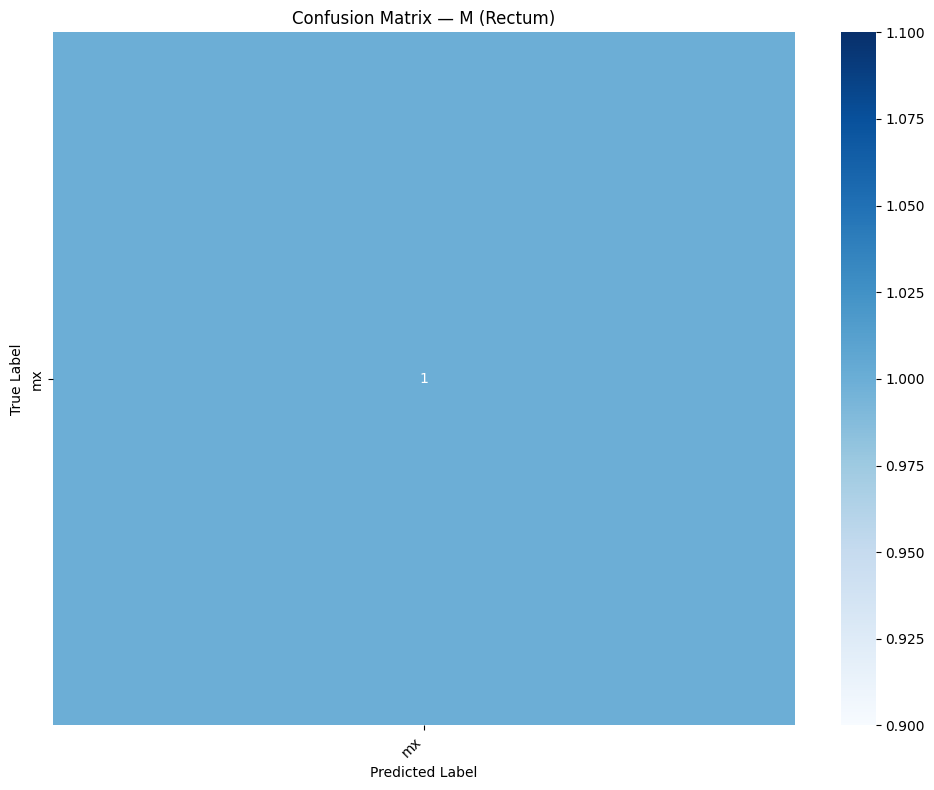


--- 📂 Category: LATER ---
📊 Classification Report:
                       precision    recall  f1-score   support

bilateral involvement       0.00      0.00      0.00       0.0
 paired, lat. unknown       0.00      0.00      0.00       1.0

             accuracy                           0.00       1.0
            macro avg       0.00      0.00      0.00       1.0
         weighted avg       0.00      0.00      0.00       1.0

🔍 Precision: 0.0000
🔍 Recall:    0.0000
🔍 F1-score:  0.0000


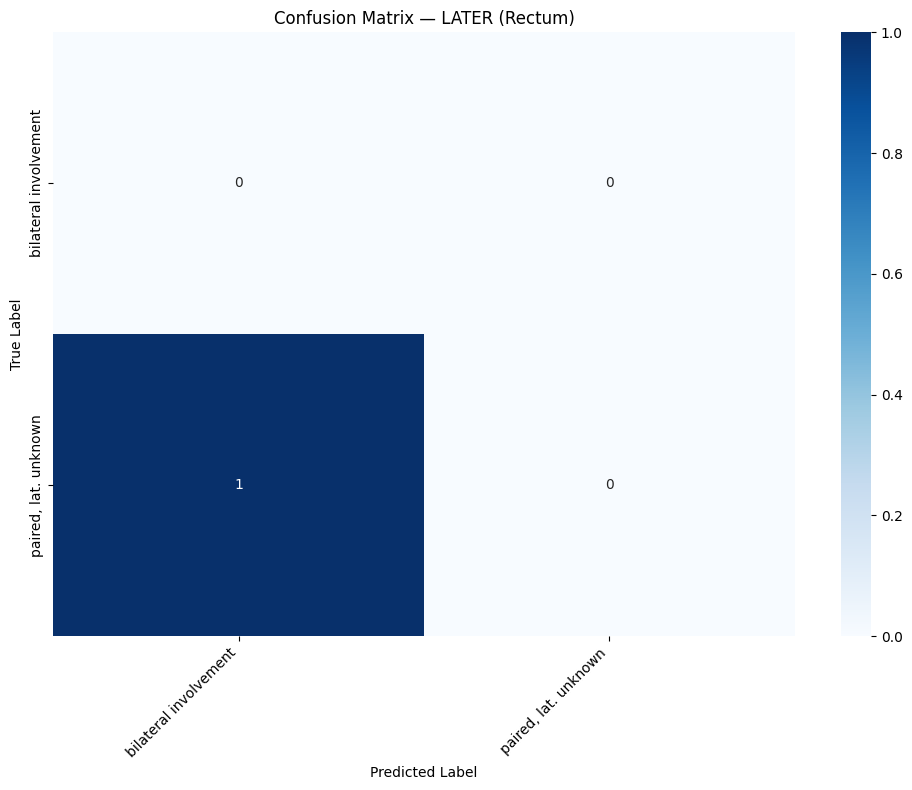

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

# Merge predictions with ground truth
combined_df = df.merge(df_pred_registry, on="mrn", how="inner")

# Define registry categories to evaluate
categories = [
    ("GRADE", "GRADE (pred)"),
    ("MORP", "MORP (pred)"),
    ("STAGE", "STAGE (pred)"),
    ("T", "T(pred)"),
    ("N", "N(pred)"),
    ("M", "M(pred)"),
    ("LATER", "LATER (pred)")
]

# Clean all category columns
for gt_col, pred_col in categories:
    combined_df[gt_col] = combined_df[gt_col].astype(str).str.lower().fillna("unknown").replace(["nan", ""], "unknown")
    combined_df[pred_col] = combined_df[pred_col].astype(str).str.lower().fillna("unknown").replace(["nan", ""], "unknown")

# Loop through each site (TOPO)
for site in combined_df["TOPO"].dropna().unique():
    print(f"\n\n==============================")
    print(f"📌 Evaluating Site: {site.upper()}")
    print(f"==============================")

    site_df = combined_df[combined_df["TOPO"] == site]

    for gt_col, pred_col in categories:
        print(f"\n--- 📂 Category: {gt_col} ---")

        gold = site_df[gt_col]
        pred = site_df[pred_col]

        # Determine all unique labels across gold & pred
        labels = sorted(list(set(gold) | set(pred)))

        # Skip if both gold and pred only contain 'unknown'
        if set(labels) == {"unknown"}:
            print("⚠️ Only 'unknown' labels found. Skipping.")
            continue

        # Compute classification metrics
        cm = confusion_matrix(gold, pred, labels=labels)
        report = classification_report(gold, pred, labels=labels, zero_division=0)
        precision = precision_score(gold, pred, average='weighted', zero_division=0)
        recall = recall_score(gold, pred, average='weighted', zero_division=0)
        f1 = f1_score(gold, pred, average='weighted', zero_division=0)

        print("📊 Classification Report:")
        print(report)
        print(f"🔍 Precision: {precision:.4f}")
        print(f"🔍 Recall:    {recall:.4f}")
        print(f"🔍 F1-score:  {f1:.4f}")

        # Plot confusion matrix
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.title(f"Confusion Matrix — {gt_col} ({site.title()})")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


**Per-Category Weighted F1-score by Site**

| Category  | Breast | Colorectal | Thyroid | Prostate |
| --------- | ------ | ---------- | ------- | -------- |
| **GRADE** | 0.8600 | 0.1275     | 0.9142  | 0.3896   |
| **MORP**  | 0.6717 | 0.0410     | 0.8892  | 0.3199   |
| **STAGE** | 0.1741 | 0.3694     | 0.0986  | 0.5538   |
| **T**     | 0.4416 | 0.5847     | 0.5838  | 0.0956   |
| **N**     | 0.7941 | 0.7315     | 0.4191  | 0.1188   |
| **M**     | 0.6298 | 0.4825     | 0.7576  | 0.1549   |
| **LATER** | 0.2631 | 0.4161     | 0.3697  | 0.3635   |


In [ ]:
combined_df.to_csv('combined_dataframe_regex.csv', index=False)
print("combined_df saved as combined_dataframe_regex.csv")

combined_df saved as combined_dataframe_regex.csv


In [ ]:
combined_df

,mrn,TOPO,MORP,GRADE,T,N,M,STAGE,LATER,TRE-1,...,site,T(pred),N(pred),M(pred),TOPO (pred),MORP (pred),GRADE (pred),STAGE (pred),TRE (pred),LATER (pred)
0,1082698,BREAST,infiltrating or invasive ductal carcinoma of n...,grade 3 or grade iii; also called poorly diffe...,t3,n0,m0,iib,left,surgery+chemotherapy+radiotherapy+hormonal,...,NaN,t3,n0,m0,BREAST,ductal carcinoma in situ (dcis),grade 3 or grade iii; also called poorly diffe...,unknown,"Hormonal therapy, Chemotherapy, Radiotherapy, ...",left
1,1092552,BREAST,infiltrating or invasive ductal carcinoma of n...,grade 3 or grade iii; also called poorly diffe...,t4b,n0,m0,iiia,right,neoadjuvant chemotherapy+surgery+radiotherapy+...,...,NaN,unknown,n0,m0,BREAST,infiltrating or invasive ductal carcinoma of n...,grade 2 or grade ii; also called moderately d...,iia,"Hormonal therapy, Chemotherapy, Surgery, Radio...",left
2,1279594,COLORECTAL,adenocarcinoma of no special type,grade 2 or grade ii; also called moderately d...,t3,n1,mx,iiib,"right, transverse colon",chemotherapy + surgery,...,NaN,t3,n1,m0,COLORECTAL,unknown,unknown,iiib,"Chemotherapy, Surgery",bilateral involvement
3,1389006,COLORECTAL,adenocarcinoma of no special type,grade 2 or grade ii; also called moderately d...,t3,n0,m0,iib,left,chemotherapy + surgery,...,NaN,t3,n0,m0,COLORECTAL,infiltrating or invasive lobular carcinoma of ...,grade 1 or grade i; also called well-different...,ii,"Chemotherapy, Radiotherapy, Surgery",bilateral involvement
4,1215135,BREAST,mucinous carcinoma,grade 2 or grade ii; also called moderately d...,t2,n0,m0,iia,left,surgery+chemotherapy+radiotherapy+hormonal,...,NaN,unknown,n0,m0,BREAST,ductal carcinoma in situ (dcis),grade 2 or grade ii; also called moderately d...,unknown,"Chemotherapy, Surgery, Radiotherapy",bilateral involvement
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
573,1359023,THYROID,papillary carcinoma,unknown,unknown,unknown,unknown,i,unknown,total thyroidectomy,...,thyroid,unknown,unknown,unknown,THYROID,papillary carcinoma,unknown,unknown,NaN,unknown
574,1365405,THYROID,papillary carcinoma,unknown,unknown,unknown,unknown,i,unknown,total thyroidectomy,...,thyroid,unknown,unknown,unknown,THYROID,papillary carcinoma,unknown,unknown,NaN,left
575,1365411,THYROID,papillary carcinoma,unknown,unknown,unknown,unknown,i,unknown,total thyroidectomy,...,thyroid,unknown,unknown,unknown,THYROID,papillary carcinoma,unknown,unknown,NaN,unknown
576,1365420,THYROID,papillary carcinoma,unknown,unknown,n1,unknown,i,unknown,total thyroidectomy,...,thyroid,t4,unknown,unknown,THYROID,infiltrating or invasive ductal carcinoma of n...,unknown,unknown,Surgery,bilateral involvement
